In [1]:
import sys
import numpy as np 
import os
import sys
import warnings
from collections import Counter
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
sys.path.append("/mnt/c/DPSlab")
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.tensorboard import SummaryWriter  # Import TensorBoard
from tqdm import tqdm
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import torch.nn.functional as F
import torchquantum as tq
import random
from torchquantum.layer import U3CU3Layer0 # Quantum Layer

from torchquantum.encoding import Encoder 
from torchquantum.functional import func_name_dict
from typing import Iterable
from torchquantum.macro import C_DTYPE #Complex Number
from abc import ABCMeta
from qiskit import QuantumCircuit #Define Circuit
from torchquantum.encoding import GeneralEncoder
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

2025-10-13 01:28:48.775065: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-13 01:28:49.916395: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760286530.302774    1504 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760286530.407216    1504 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760286531.418189    1504 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 14623902112441277491
 xla_global_id: -1,
 name: "/device:GPU:0"
 device_type: "GPU"
 memory_limit: 14154727424
 locality {
   bus_id: 1
   links {
   }
 }
 incarnation: 4006703415955164610
 physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9"
 xla_global_id: 416903419]

In [ ]:
# ==============================
# Global Conventions (Detection)
# ==============================

import math
from typing import Optional
import torch
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------
# 0) Reproducibility
# ------------------------------
def set_global_seed(seed: int = 42) -> None:
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False

# ------------------------------
# 1) Box format conversions
# ------------------------------
@torch.no_grad()
def xyxy_to_cxcywh(b: torch.Tensor) -> torch.Tensor:
    x1,y1,x2,y2 = b.unbind(-1)
    w = (x2 - x1).clamp_min(0.0)
    h = (y2 - y1).clamp_min(0.0)
    cx = x1 + 0.5 * w
    cy = y1 + 0.5 * h
    return torch.stack([cx, cy, w, h], dim=-1)

@torch.no_grad()
def cxcywh_to_xyxy(b: torch.Tensor) -> torch.Tensor:
    cx,cy,w,h = b.unbind(-1)
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack([x1, y1, x2, y2], dim=-1)

# ------------------------------
# 2) Sanitize & Validity
# ------------------------------
@torch.no_grad()
def sanitize_xyxy(b: torch.Tensor, H: int, W: int) -> torch.Tensor:
    x1,y1,x2,y2 = b.unbind(-1)
    x1_, x2_ = torch.minimum(x1,x2), torch.maximum(x1,x2)
    y1_, y2_ = torch.minimum(y1,y2), torch.maximum(y1,y2)
    return torch.stack([
        x1_.clamp(0,W-1), y1_.clamp(0,H-1),
        x2_.clamp(0,W-1), y2_.clamp(0,H-1)
    ], dim=-1)

@torch.no_grad()
def valid_box_mask_xyxy(b: torch.Tensor, min_size: float = 1.0) -> torch.Tensor:
    w = (b[...,2] - b[...,0])
    h = (b[...,3] - b[...,1])
    return (w >= min_size) & (h >= min_size)

# ------------------------------
# 3) Δ Encoding / Decoding
# ------------------------------
@torch.no_grad()
def encode_deltas(gt_xyxy: torch.Tensor, anc_cxcywh: torch.Tensor) -> torch.Tensor:
    gt_c = xyxy_to_cxcywh(gt_xyxy)
    cx,cy,w,h = anc_cxcywh.unbind(-1)
    gx,gy,gw,gh = gt_c.unbind(-1)
    w = w.clamp_min(1e-6); h = h.clamp_min(1e-6)
    tx = (gx - cx) / w
    ty = (gy - cy) / h
    tw = torch.log(gw.clamp_min(1e-6) / w)
    th = torch.log(gh.clamp_min(1e-6) / h)
    return torch.stack([tx, ty, tw, th], dim=-1)

@torch.no_grad()
def decode_deltas(anc_cxcywh: torch.Tensor, deltas: torch.Tensor, clamp_log: float = 2.0) -> torch.Tensor:
    cx,cy,w,h = anc_cxcywh.unbind(-1)
    tx,ty,tw,th = deltas.unbind(-1)
    if clamp_log is not None:
        tw = tw.clamp(-clamp_log, clamp_log)
        th = th.clamp(-clamp_log, clamp_log)
    px = cx + tx * w
    py = cy + ty * h
    pw = w * torch.exp(tw)
    ph = h * torch.exp(th)
    return cxcywh_to_xyxy(torch.stack([px, py, pw, ph], dim=-1))

# ------------------------------
# 4) Score Combination
# ------------------------------
def combine_scores(obj_logits: torch.Tensor, cls_logits: torch.Tensor, labels: Optional[torch.Tensor] = None):
    if obj_logits.ndim == 3 and obj_logits.size(-1) == 1:
        obj_logits = obj_logits.squeeze(-1)
    obj_prob = obj_logits.sigmoid()
    cls_prob = F.softmax(cls_logits, dim=-1)
    if labels is None:
        return obj_prob.unsqueeze(-1) * cls_prob
    else:
        B,N,C = cls_prob.shape
        idx = labels.clamp_min(0)
        gathered = cls_prob.gather(-1, idx.view(B,N,1)).squeeze(-1)
        return obj_prob * gathered

# ------------------------------
# 5) Bias Initializers
# ------------------------------
def init_obj_bias(module: nn.Module, pi: float = 0.01) -> None:
    if getattr(module, "bias", None) is not None:
        with torch.no_grad():
            module.bias.fill_(math.log(pi / (1 - pi)))

def init_cls_bias(module: nn.Module, class_priors: torch.Tensor) -> None:
    prior = class_priors / class_priors.clamp_min(1e-12).sum()
    bias = torch.log(prior.clamp_min(1e-12))
    if getattr(module, "bias", None) is not None:
        with torch.no_grad():
            if module.bias.numel() == bias.numel():
                module.bias.copy_(bias)
            else:
                A = module.bias.numel() // bias.numel()
                module.bias.copy_(bias.repeat(A))

# ------------------------------
# 6) Smoke Test
# ------------------------------
@torch.no_grad()
def _iou_xyxy(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    x1 = torch.maximum(a[:,0], b[:,0]); y1 = torch.maximum(a[:,1], b[:,1])
    x2 = torch.minimum(a[:,2], b[:,2]); y2 = torch.minimum(a[:,3], b[:,3])
    inter = (x2 - x1).clamp_min(0) * (y2 - y1).clamp_min(0)
    area_a = (a[:,2]-a[:,0]).clamp_min(0) * (a[:,3]-a[:,1]).clamp_min(0)
    area_b = (b[:,2]-b[:,0]).clamp_min(0) * (b[:,3]-b[:,1]).clamp_min(0)
    union = (area_a + area_b - inter).clamp_min(1e-6)
    return inter / union

@torch.no_grad()
def _round_trip_delta_smoke() -> None:
    anc = torch.tensor([[50.,50.,40.,20.],[20.,30.,10.,10.]], dtype=torch.float32)
    gt  = torch.tensor([[40.,40.,60.,60.],[15.,25.,25.,35.]], dtype=torch.float32)
    d   = encode_deltas(gt, anc)
    pred = decode_deltas(anc, d, clamp_log=None)
    iou = _iou_xyxy(pred, gt)
    print("[SMOKE] mean IoU round-trip:", float(iou.diag().mean().item()))

# if __name__ == "__main__":
#     set_global_seed(123)
#     _round_trip_delta_smoke()
#     print("globals: OK")


# Dataset

In [3]:
# ============================================
# Dataset (픽셀/xyxy 규약 고정) + Loader + 시각화
# ============================================

import os, json, torch
from glob import glob
from collections import defaultdict
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader

# ----- 전역 경로/클래스 -----
DATA_ROOT = "/mnt/c/DPSlab/qcnn/Highway-classification-1-downsampled"

CLASS_NAMES = ["car", "motorcycle", "truck"]
NUM_CLASSES = len(CLASS_NAMES)
NAME2IDX = {"car": 0, "motorcycle": 1, "truck": 2}

def _canon_name(s):
    return " ".join(s.lower().split()) if isinstance(s, str) else None

# ----- 규약 유틸 (픽셀/xyxy) -----
@torch.no_grad()
def _xywh_to_xyxy_box(xywh):
    x,y,w,h = xywh
    return [x, y, x + max(w,0.0), y + max(h,0.0)]

@torch.no_grad()
def _sanitize_xyxy(b, H, W, min_size=1.0):
    x1,y1,x2,y2 = b.unbind(-1)
    x1_, x2_ = torch.minimum(x1,x2), torch.maximum(x1,x2)
    y1_, y2_ = torch.minimum(y1,y2), torch.maximum(y1,y2)
    b = torch.stack([
        x1_.clamp(0, W-1), y1_.clamp(0, H-1),
        x2_.clamp(0, W-1), y2_.clamp(0, H-1)
    ], dim=-1)
    w = b[:,2] - b[:,0]; h = b[:,3] - b[:,1]
    keep = (w >= min_size) & (h >= min_size)
    return b[keep], keep

# ----- Split 로딩 -----
def load_split_from_folder(split_name: str):
    split_root = os.path.join(DATA_ROOT, split_name)
    ann_path = os.path.join(split_root, "_annotations.coco.json")
    img_dir  = split_root
    image_to_anns = defaultdict(list)

    if not os.path.exists(ann_path):
        print(f"[경고] {ann_path} 없음")
        return image_to_anns

    with open(ann_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    id2file = {im["id"]: im["file_name"] for im in data.get("images", [])}
    id2name = {c["id"]: c["name"] for c in data.get("categories", [])}

    for ann in data.get("annotations", []):
        cid = ann.get("category_id")
        idx = None
        if isinstance(cid, int) and 0 <= cid < NUM_CLASSES:
            idx = cid
        else:
            cname = id2name.get(cid)
            ckey = _canon_name(cname)
            if ckey in NAME2IDX:
                idx = NAME2IDX[ckey]
        if idx is None:
            continue
        img_file = id2file.get(ann["image_id"])
        if not img_file:
            continue
        img_path = os.path.join(img_dir, img_file)
        if not os.path.exists(img_path):
            continue
        bbox_xywh = ann.get("bbox")
        if bbox_xywh and len(bbox_xywh) == 4:
            image_to_anns[img_path].append((bbox_xywh, idx))
    return image_to_anns

# ============================================
# 🚫 truck 클래스(2번) 제외
# ============================================
train_dict = load_split_from_folder("train")
test_dict  = load_split_from_folder("test")

CLASS_NAMES = ["car", "motorcycle"]
NAME2IDX = {"car": 0, "motorcycle": 1}
NUM_CLASSES = len(CLASS_NAMES)

def remove_truck_entries(image_to_anns, truck_idx=2):
    new_dict = {}
    for img_path, anns in image_to_anns.items():
        filtered = [(bbox, cid) for (bbox, cid) in anns if cid != truck_idx]
        if len(filtered) > 0:
            new_dict[img_path] = filtered
    return new_dict

train_dict = remove_truck_entries(train_dict)
test_dict  = remove_truck_entries(test_dict)

print(f"After filtering: train={len(train_dict)} images, test={len(test_dict)} images (truck 제외)")

# ----- Dataset -----
class PotholeDetectionDataset(Dataset):
    def __init__(self, image_to_anns, transform=None, target_size=(90,160), min_box=1.0):
        self.samples = list(image_to_anns.items())
        self.transform = transform
        self.target_h, self.target_w = target_size
        self.min_box = float(min_box)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, anns = self.samples[idx]
        img = Image.open(img_path).convert("L")
        orig_w, orig_h = img.size
        new_h, new_w = self.target_h, self.target_w
        scale_x, scale_y = new_w / orig_w, new_h / orig_h
        xform = self.transform or v2.Compose([
            v2.Resize((new_h, new_w)),
            v2.ToTensor(),
        ])
        img_t = xform(img)
        boxes_xyxy, labels = [], []
        for (xywh, cid_idx) in anns:
            x1,y1,x2,y2 = _xywh_to_xyxy_box(xywh)
            x1 *= scale_x; x2 *= scale_x
            y1 *= scale_y; y2 *= scale_y
            boxes_xyxy.append([x1,y1,x2,y2])
            labels.append(cid_idx)
        if boxes_xyxy:
            boxes_t = torch.tensor(boxes_xyxy, dtype=torch.float32)
            labels_t= torch.tensor(labels, dtype=torch.int64)
            boxes_t, keep = _sanitize_xyxy(boxes_t, H=new_h, W=new_w, min_size=self.min_box)
            labels_t = labels_t[keep]
        else:
            boxes_t  = torch.zeros((0,4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
        return img_t, {"boxes": boxes_t, "labels": labels_t}

# ----- Transforms & Loaders -----
IMAGE_SIZE = (416, 416)
mean, std = [0.3763], [0.3013]
train_tf = v2.Compose([v2.Resize(IMAGE_SIZE), v2.ToTensor(), v2.Normalize(mean, std)])
test_tf  = v2.Compose([v2.Resize(IMAGE_SIZE), v2.ToTensor(), v2.Normalize(mean, std)])

train_dataset = PotholeDetectionDataset(train_dict, transform=train_tf, target_size=IMAGE_SIZE)
test_dataset  = PotholeDetectionDataset(test_dict,  transform=test_tf,  target_size=IMAGE_SIZE)

def detection_collate_fn(batch):
    images  = [b[0] for b in batch]
    targets = [b[1] for b in batch]
    return images, targets

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          collate_fn=detection_collate_fn, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False,
                          collate_fn=detection_collate_fn, num_workers=4, pin_memory=True)

print(f"Train images: {len(train_dataset)}")
print(f"Test  images: {len(test_dataset)}")

# ----- 시각화 -----
VIZ_MEAN, VIZ_STD = mean, std
def _denorm_1ch(img_t, mean, std):
    mean_t = torch.tensor(mean, dtype=img_t.dtype, device=img_t.device)[:, None, None]
    std_t  = torch.tensor(std,  dtype=img_t.dtype, device=img_t.device)[:, None, None]
    x = (img_t * std_t + mean_t).clamp(0, 1)
    return x[0].detach().cpu().numpy()

def show_sample_xyxy(dataset, idx, with_labels=True):
    img_t, target = dataset[idx]
    img_np = _denorm_1ch(img_t, VIZ_MEAN, VIZ_STD)
    boxes = target["boxes"].detach().cpu().numpy()
    labels= target["labels"].detach().cpu().numpy()
    plt.figure(figsize=(5,3))
    plt.imshow(img_np, cmap="gray")
    H,W = img_np.shape
    for b, lb in zip(boxes, labels):
        x1,y1,x2,y2 = b
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=1.5)
        plt.gca().add_patch(rect)
        if with_labels:
            plt.text(x1, y1-2, CLASS_NAMES[int(lb)], fontsize=8,
                     bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))
    plt.axis("off"); plt.title(f"idx={idx}")
    plt.show()

After filtering: train=993 images, test=244 images (truck 제외)
Train images: 993
Test  images: 244


In [4]:
# ============================================
# 📊 클래스별 이미지/바운딩박스 통계 출력
# ============================================
from collections import defaultdict

def compute_class_stats(image_to_anns):
    img_count = defaultdict(set)
    bbox_count = defaultdict(int)

    for img_path, anns in image_to_anns.items():
        for _, cid in anns:
            cname = CLASS_NAMES[cid]
            img_count[cname].add(img_path)
            bbox_count[cname] += 1

    print("=== 클래스별 통계 ===")
    for cname in CLASS_NAMES:
        n_img = len(img_count[cname])
        n_box = bbox_count[cname]
        print(f"{cname:<12} | 이미지 {n_img:4d}장 | bbox {n_box:6d}개")

print("\n[TRAIN SPLIT]")
compute_class_stats(train_dict)

print("\n[TEST SPLIT]")
compute_class_stats(test_dict)


[TRAIN SPLIT]
=== 클래스별 통계 ===
car          | 이미지  712장 | bbox    991개
motorcycle   | 이미지  766장 | bbox   1053개

[TEST SPLIT]
=== 클래스별 통계 ===
car          | 이미지  179장 | bbox    245개
motorcycle   | 이미지  156장 | bbox    211개


[미리보기] car → idx=0


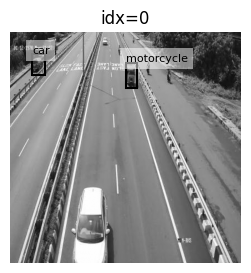

[미리보기] motorcycle → idx=0


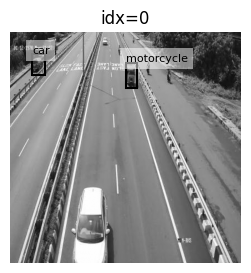

In [5]:
def find_first_idx_of_class(dataset, cls_idx):
   for i in range(len(dataset)):
       _, t = dataset[i]
       if (t["labels"] == cls_idx).any():
           return i
   return None
for ci, cn in enumerate(CLASS_NAMES):
   idx = find_first_idx_of_class(train_dataset, ci)
   print(f"[미리보기] {cn} → idx={idx}")
   if idx is not None: show_sample_xyxy(train_dataset, idx)

# anchor_generator

In [6]:
# ============================================
# Anchors (FINAL_PRESET): 스케일 촘촘화 + P2 강화 + L2 경계보강
# ============================================
import math, torch
from typing import List, Tuple, Dict
from torchvision.ops import box_iou

# -------------------- 유틸 --------------------
@torch.no_grad()
def cxcywh_to_xyxy(x: torch.Tensor) -> torch.Tensor:
    cx, cy, w, h = x.unbind(-1)
    return torch.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], dim=-1)

@torch.no_grad()
def make_anchors_level_with_offsets(H_img:int, W_img:int, Hs:int, Ws:int,
                                    scales:torch.Tensor, ratios:Tuple[float,...],
                                    offsets:Tuple[float,...]=(0.5,),
                                    device=torch.device("cpu")) -> torch.Tensor:
    s = scales.to(device).view(-1,1)
    r = torch.tensor(ratios, device=device, dtype=torch.float32).view(1,-1)
    ws = (s*torch.sqrt(r)).reshape(-1)
    hs = (s/torch.sqrt(r)).reshape(-1)
    A = ws.numel()

    out = []
    for off in offsets:
        sy, sx = H_img/float(Hs), W_img/float(Ws)
        ys = (torch.arange(Hs, device=device)+off)*sy
        xs = (torch.arange(Ws, device=device)+off)*sx
        cy, cx = torch.meshgrid(ys, xs, indexing="ij")
        centers = torch.stack([cx.reshape(-1), cy.reshape(-1)], dim=-1)
        N = centers.size(0)
        cx_all = centers[:,0].unsqueeze(1).expand(N, A).reshape(-1)
        cy_all = centers[:,1].unsqueeze(1).expand(N, A).reshape(-1)
        w_all  = ws.unsqueeze(0).expand(N, A).reshape(-1)
        h_all  = hs.unsqueeze(0).expand(N, A).reshape(-1)
        anc = torch.stack([cx_all, cy_all, w_all, h_all], dim=-1)
        anc[:,2] = anc[:,2].clamp(1.0, W_img-1)
        anc[:,3] = anc[:,3].clamp(1.0, H_img-1)
        out.append(anc)
    return torch.cat(out, dim=0).contiguous()

@torch.no_grad()
def build_anchors_pyramid(H_img:int, W_img:int,
                          strides:List[int],
                          scales_per_level:List[torch.Tensor],
                          ratios_per_level:List[Tuple[float,...]],
                          offsets_per_level:List[Tuple[float,...]],
                          device=torch.device("cpu")) -> Tuple[torch.Tensor, Dict[int, slice]]:
    all_list, slices = [], {}
    start = 0
    for li, (stride, scales, ratios, offsets) in enumerate(zip(strides, scales_per_level, ratios_per_level, offsets_per_level)):
        Hs = math.ceil(H_img / stride); Ws = math.ceil(W_img / stride)
        anc = make_anchors_level_with_offsets(H_img, W_img, Hs, Ws, scales, ratios, offsets, device=device)
        end = start + anc.size(0)
        slices[li] = slice(start, end); start = end
        per_loc = len(scales)*len(ratios)*len(offsets)
        print(f"[LEVEL {li}] stride={stride} fmap={Hs}x{Ws} | per-loc={per_loc} | anchors={anc.size(0)}")
        all_list.append(anc)
    return torch.cat(all_list, dim=0).contiguous(), slices

@torch.no_grad()
def measure_anchor_coverage(dataset, anchors_xyxy_cpu: torch.Tensor,
                            per_level_slices:Dict[int, slice]=None,
                            thresholds=(0.3, 0.5)) -> None:
    all_max=[]; level_max={k: [] for k in (per_level_slices or {}).keys()}
    for i in range(len(dataset)):
        _, tgt = dataset[i]; gt = tgt["boxes"].float()
        if gt.numel()==0: continue
        A = anchors_xyxy_cpu.to(gt.device, non_blocking=True)
        m = box_iou(A, gt).max(dim=0).values; all_max.append(m.cpu())
        if per_level_slices:
            for li, s in per_level_slices.items():
                ml = box_iou(A[s], gt).max(dim=0).values; level_max[li].append(ml.cpu())
    if not all_max:
        print("[COVER] No GT."); return
    S = torch.cat(all_max)
    def summ(name,v):
        msg=f"{name}: mean={v.mean():.3f} | median={v.median():.3f} | p90={v.quantile(0.9):.3f}"
        for t in thresholds: msg+=f" | frac(≥{t})={(v>=t).float().mean()*100:.1f}%"
        print(msg)
    print("----- Coverage (ALL anchors) -----"); summ("ALL", S)
    if per_level_slices:
        print("----- Coverage (Per level) -----")
        for li in per_level_slices:
            if level_max[li]:
                v=torch.cat(level_max[li]); summ(f"LEVEL {li}", v)

# ============================================
# FINAL_PRESET
# 외부 전역: IMAGE_SIZE=(H,W), train_dataset, test_dataset 제공됨
# ============================================
H_img, W_img = IMAGE_SIZE

# 레벨/스트라이드
strides = [4, 8, 16]

# L0 (P2): 초소형 유지, 듀얼 오프셋(중심/격자)
scales_p2  = torch.tensor([1.6, 2.2, 3.2, 4.5, 6.0], dtype=torch.float32)
ratios_p2  = (0.33, 0.5, 1.0, 2.0)
offsets_p2 = (0.5, 0.0)   # per-loc = 5*4*2 = 40

# L1 (P3): 중형, 경계 보강 오프셋
scales_p3  = torch.tensor([8.0, 10.5, 13.0, 16.0], dtype=torch.float32)
ratios_p3  = (0.5, 1.0, 2.0, 3.0)
offsets_p3 = (0.25, 0.75) # per-loc = 4*4*2 = 32

# L2 (P4): 혼합 mid+large 스케일 + 경계 보강 오프셋  ← 최종 확정
scales_p4  = torch.tensor([18.0, 22.0, 26.0, 30.0, 36.0, 44.0], dtype=torch.float32)
ratios_p4  = (0.5, 1.0)
offsets_p4 = (0.25, 0.75) # per-loc = 6*2*2 = 24

ratios_per_level   = [ratios_p2, ratios_p3, ratios_p4]
offsets_per_level  = [offsets_p2, offsets_p3, offsets_p4]
scales_per_level   = [scales_p2, scales_p3, scales_p4]

# -------- 앵커 생성 & 커버리지 측정 --------
anchors_cxcywh, level_slices = build_anchors_pyramid(
    H_img, W_img,
    strides=strides,
    scales_per_level=scales_per_level,
    ratios_per_level=ratios_per_level,
    offsets_per_level=offsets_per_level,
    device=torch.device("cpu"),
)

anchors_xyxy = cxcywh_to_xyxy(anchors_cxcywh).contiguous()
print(f"[ANCHORS] total={anchors_xyxy.size(0)}")
print("[CHECK] FINAL_PRESET | L2 scales:", list(map(float, scales_p4)), "| L2 offsets:", offsets_p4)

print("\n=== TRAIN COVERAGE ===")
measure_anchor_coverage(train_dataset, anchors_xyxy, level_slices, thresholds=(0.3,0.5))

print("\n=== TEST COVERAGE ===")
measure_anchor_coverage(test_dataset, anchors_xyxy, level_slices, thresholds=(0.3,0.5))


[LEVEL 0] stride=4 fmap=104x104 | per-loc=40 | anchors=432640
[LEVEL 1] stride=8 fmap=52x52 | per-loc=32 | anchors=86528
[LEVEL 2] stride=16 fmap=26x26 | per-loc=24 | anchors=16224
[ANCHORS] total=535392
[CHECK] FINAL_PRESET | L2 scales: [18.0, 22.0, 26.0, 30.0, 36.0, 44.0] | L2 offsets: (0.25, 0.75)

=== TRAIN COVERAGE ===
----- Coverage (ALL anchors) -----
ALL: mean=0.701 | median=0.698 | p90=0.803 | frac(≥0.3)=100.0% | frac(≥0.5)=99.8%
----- Coverage (Per level) -----
LEVEL 0: mean=0.035 | median=0.034 | p90=0.055 | frac(≥0.3)=0.0% | frac(≥0.5)=0.0%
LEVEL 1: mean=0.251 | median=0.240 | p90=0.390 | frac(≥0.3)=32.7% | frac(≥0.5)=0.0%
LEVEL 2: mean=0.701 | median=0.698 | p90=0.803 | frac(≥0.3)=100.0% | frac(≥0.5)=99.8%

=== TEST COVERAGE ===
----- Coverage (ALL anchors) -----
ALL: mean=0.708 | median=0.705 | p90=0.815 | frac(≥0.3)=99.8% | frac(≥0.5)=99.6%
----- Coverage (Per level) -----
LEVEL 0: mean=0.034 | median=0.032 | p90=0.054 | frac(≥0.3)=0.0% | frac(≥0.5)=0.0%
LEVEL 1: mean=0.

In [7]:
# 이미지 크기
H_img, W_img = IMAGE_SIZE

anchors_cfg = {
    "scales": [16, 24, 32, 40, 48, 56],   # bbox 크기 분포를 커버
    "ratios": [0.5, 1.0, 2.0, 2.5],       # 세로긴 물체 대응 위해 2.0~2.5 추가
}

# anchors_cfg 기반으로 앵커 생성 (stride=8, offset=0.5 가정)
scales = torch.tensor(anchors_cfg["scales"], dtype=torch.float32)
ratios = tuple(anchors_cfg["ratios"])
offsets = (0.5,)   # 기본 오프셋

Hs = math.ceil(H_img / 8)
Ws = math.ceil(W_img / 8)

anchors_cxcywh = make_anchors_level_with_offsets(
    H_img, W_img, Hs, Ws,
    scales, ratios, offsets,
    device=torch.device("cpu")
)

anchors_xyxy = cxcywh_to_xyxy(anchors_cxcywh).contiguous()
print(f"[ANCHORS_CUSTOM] total={anchors_xyxy.size(0)} "
      f"| scales={anchors_cfg['scales']} | ratios={anchors_cfg['ratios']}")

print("\n=== TRAIN COVERAGE (custom) ===")
measure_anchor_coverage(train_dataset, anchors_xyxy, thresholds=(0.3,0.5))

print("\n=== TEST COVERAGE (custom) ===")
measure_anchor_coverage(test_dataset, anchors_xyxy, thresholds=(0.3,0.5))


[ANCHORS_CUSTOM] total=64896 | scales=[16, 24, 32, 40, 48, 56] | ratios=[0.5, 1.0, 2.0, 2.5]

=== TRAIN COVERAGE (custom) ===
----- Coverage (ALL anchors) -----
ALL: mean=0.732 | median=0.736 | p90=0.831 | frac(≥0.3)=100.0% | frac(≥0.5)=99.8%

=== TEST COVERAGE (custom) ===
----- Coverage (ALL anchors) -----
ALL: mean=0.737 | median=0.740 | p90=0.833 | frac(≥0.3)=99.8% | frac(≥0.5)=99.6%


In [8]:
# --- 대형 IoU 행렬을 안전하게 계산 (chunk) ---
@torch.no_grad()
def max_iou_per_anchor_chunked(anchors_xyxy: torch.Tensor, gt_xyxy: torch.Tensor, chunk=20000):
    # 반환: iou_max:[N], iou_argmax:[N] (각 앵커에 대해 최대 IoU 및 그 GT 인덱스)
    N = anchors_xyxy.size(0)
    iou_max = torch.zeros(N, device=anchors_xyxy.device)
    iou_arg = torch.full((N,), -1, dtype=torch.long, device=anchors_xyxy.device)
    for s in range(0, N, chunk):
        e = min(s+chunk, N)
        iou = box_iou(anchors_xyxy[s:e], gt_xyxy)  # [e-s, M]
        val, idx = (iou.max(dim=1) if gt_xyxy.numel() else (torch.zeros(e-s, device=iou.device), torch.full((e-s,), -1, dtype=torch.long, device=iou.device)))
        iou_max[s:e] = val
        iou_arg[s:e] = idx
    return iou_max, iou_arg

# --- GT별로 최소 1개 양성을 보장 (best-match) ---
@torch.no_grad()
def force_at_least_one_positive(anchors_xyxy: torch.Tensor, gt_xyxy: torch.Tensor, iou_matrix=None):
    if gt_xyxy.numel() == 0:
        return torch.tensor([], dtype=torch.long, device=anchors_xyxy.device)
    if iou_matrix is None:
        iou_matrix = box_iou(anchors_xyxy, gt_xyxy)  # [N, M]
    # 각 GT에 대해 IoU가 최대인 앵커 인덱스
    best_anchor_idx = iou_matrix.argmax(dim=0)  # [M]
    return best_anchor_idx.unique()

# --- 매칭 & 타깃 생성 ---
@torch.no_grad()
def build_targets_for_image(anchors_cxcywh: torch.Tensor,
                            anchors_xyxy: torch.Tensor,
                            gt_xyxy: torch.Tensor,
                            gt_labels: torch.Tensor,
                            iou_pos=0.5, iou_neg=0.3,
                            clamp_log=2.0,
                            chunk=20000):
    N = anchors_xyxy.size(0)
    device = anchors_xyxy.device

    tgt_obj    = torch.zeros(N, dtype=torch.float32, device=device)  # 1 pos / 0 neg (ignore는 valid_mask로 제외)
    valid_mask = torch.zeros(N, dtype=torch.bool, device=device)     # 손실 포함 여부
    tgt_labels = torch.full((N,), -1, dtype=torch.long, device=device)
    tgt_delta  = torch.zeros(N, 4, dtype=torch.float32, device=device)

    if gt_xyxy.numel() == 0:
        # 전부 음성으로 학습할지 여부는 설정에 따라 다르나, 여기선 음성 유효로 둔다
        valid_mask[:] = True
        tgt_obj[:] = 0.0
        return tgt_obj, valid_mask, tgt_labels, tgt_delta

    # 1) 앵커 기준 최대 IoU와 해당 GT 인덱스
    iou_max, iou_arg = max_iou_per_anchor_chunked(anchors_xyxy, gt_xyxy, chunk=chunk)

    # 2) 기본 레이블링: pos/neg/ignore
    pos = iou_max >= iou_pos
    neg = iou_max <= iou_neg
    ign = (~pos) & (~neg)

    # 3) 각 GT가 최소 1개 이상 pos를 갖도록 보정
    #    (이미 pos인 앵커가 있으면 유지, 없으면 best-anchor를 강제 pos)
    #    큰 매트릭스 피하려고 chunk 없이 한 번에 계산 (M 작다고 가정)
    iou_matrix = box_iou(anchors_xyxy, gt_xyxy)  # [N,M]
    best_idx = force_at_least_one_positive(anchors_xyxy, gt_xyxy, iou_matrix)
    pos[best_idx] = True
    ign[best_idx] = False
    neg[best_idx] = False

    # 4) 타깃 채우기
    valid_mask = pos | neg           # ignore는 학습 제외
    tgt_obj[pos] = 1.0
    tgt_obj[neg] = 0.0

    # pos 위치의 클래스/델타
    pos_gt_idx = iou_matrix[pos].argmax(dim=1)  # 각 양성 앵커의 GT 선택(해당 행에서 최대 IoU)
    pos_labels = gt_labels[pos_gt_idx].clamp_min(0)
    tgt_labels[pos] = pos_labels

    deltas = encode_deltas(gt_xyxy[pos_gt_idx], anchors_cxcywh[pos])
    # tw/th 안정화 클램프
    deltas[:, 2:] = deltas[:, 2:].clamp(-clamp_log, clamp_log)
    tgt_delta[pos] = deltas

    # 디버그 요약
    n_pos = int(pos.sum()); n_neg = int(neg.sum()); n_ign = int(ign.sum())
    return tgt_obj, valid_mask, tgt_labels, tgt_delta

# --- 배치 유틸 (DataLoader 샘플 1개로 스모크) ---
@torch.no_grad()
def smoke_match_batch(dataset, anchors_cxcywh, anchors_xyxy, iou_pos=0.5, iou_neg=0.3):
    img, tgt = dataset[0]
    gt = tgt["boxes"].float()
    gl = tgt["labels"].long()
    to, vm, tl, td = build_targets_for_image(
        anchors_cxcywh.to(gt.device),
        anchors_xyxy.to(gt.device),
        gt, gl, iou_pos=iou_pos, iou_neg=iou_neg
    )
    pos = (to > 0.5) & vm
    neg = (to <= 0.5) & vm
    print(f"[MATCH] N={len(to)} | pos={int(pos.sum())} | neg={int(neg.sum())} | ignore={int((~vm).sum())}")
    if pos.any():
        print("[MATCH] Δ stats (pos) mean:", td[pos].mean(0).tolist(), " | abs-max:", td[pos].abs().amax(0).tolist())
    else:
        print("[경고] 양성 없음 — iou_pos 낮추거나 스케일/ratio 재점검 필요")

# 실행: 한 샘플 스모크
smoke_match_batch(train_dataset, anchors_cxcywh, anchors_xyxy, iou_pos=0.5, iou_neg=0.3)

[MATCH] N=64896 | pos=27 | neg=64609 | ignore=260
[MATCH] Δ stats (pos) mean: [-0.025919273495674133, 0.00790842529386282, -0.13432256877422333, 0.00521933613345027]  | abs-max: [0.2872621417045593, 0.2708333432674408, 0.5108255743980408, 0.43286406993865967]


# Loss Function

In [9]:
# ============================================================
# Detection Loss Utils (OBJ/BOX/CLS) + 배치 타깃 빌더 + priors
# 규약 고정: 픽셀/xyxy, Δ=(gx-cx)/w,(gy-cy)/h,log(gw/w),log(gh/h)
# 기대 출력: obj_logits [B,N], bbox_deltas [B,N,4], cls_logits [B,N,C]
# ============================================================
import math, torch
import torch.nn.functional as F
from collections import Counter

# --- Dataset에서 클래스 prior 추출 (bias 초기화에 사용) ---
def class_priors_from_dataset(dataset, num_classes):
    cnt = Counter()
    for i in range(len(dataset)):
        _, t = dataset[i]
        for lb in t["labels"].tolist():
            cnt[int(lb)] += 1
    tot = sum(cnt.values()) + 1e-12
    priors = torch.tensor([cnt.get(c,0)/tot for c in range(num_classes)], dtype=torch.float32)
    return priors.clamp_min(1e-8) / priors.sum()

# --- 배치 타깃 생성 (각 이미지별 build_targets_for_image 사용) ---
@torch.no_grad()
def build_targets_for_batch(batch_targets, anchors_cxcywh, anchors_xyxy,
                            iou_pos=0.5, iou_neg=0.3, clamp_log=2.0, chunk=20000):
    B = len(batch_targets); N = anchors_xyxy.size(0)
    tgt_obj    = torch.zeros(B, N, dtype=torch.float32)
    valid_mask = torch.zeros(B, N, dtype=torch.bool)
    tgt_labels = torch.full((B, N), -1, dtype=torch.long)
    tgt_delta  = torch.zeros(B, N, 4, dtype=torch.float32)

    for i, t in enumerate(batch_targets):
        gt  = t["boxes"].float()
        glb = t["labels"].long()
        to, vm, tl, td = build_targets_for_image(
            anchors_cxcywh, anchors_xyxy, gt, glb,
            iou_pos=iou_pos, iou_neg=iou_neg, clamp_log=clamp_log, chunk=chunk
        )
        tgt_obj[i]    = to.cpu()
        valid_mask[i] = vm.cpu()
        tgt_labels[i] = tl.cpu()
        tgt_delta[i]  = td.cpu()
    return tgt_obj, valid_mask, tgt_labels, tgt_delta  # CPU 텐서 반환

# --- 손실 계산 (중립 제외; CLS/BOX는 양성만) ---
def detection_losses(obj_logits, bbox_deltas, cls_logits,
                     tgt_obj, valid_mask, tgt_labels, tgt_delta,
                     cls_weight=0.5, box_weight=1.0, pos_weight=None):
    """
    obj_logits: [B,N] or [B,N,1]
    bbox_deltas: [B,N,4]
    cls_logits: [B,N,C]
    *_tgt: CPU 텐서면 .to(device)로 이관
    """
    device = obj_logits.device
    if obj_logits.ndim == 3 and obj_logits.size(-1) == 1:
        obj_logits = obj_logits.squeeze(-1)

    tgt_obj    = tgt_obj.to(device)
    valid_mask = valid_mask.to(device)
    tgt_labels = tgt_labels.to(device)
    tgt_delta  = tgt_delta.to(device)

    # OBJ: BCEWithLogits(중립 제외)
    if pos_weight is not None:
        pw = torch.tensor([pos_weight], device=device)
    else:
        pw = None
    obj_loss = F.binary_cross_entropy_with_logits(
        obj_logits[valid_mask], tgt_obj[valid_mask], pos_weight=pw
    ) if valid_mask.any() else torch.tensor(0.0, device=device)

    # POS 마스크
    pos_mask = (tgt_obj > 0.5) & valid_mask
    n_pos = int(pos_mask.sum().item())

    # BOX: SmoothL1 (β=1.0) on positives
    if n_pos > 0:
        box_loss = F.smooth_l1_loss(bbox_deltas[pos_mask], tgt_delta[pos_mask], beta=1.0)
    else:
        box_loss = torch.tensor(0.0, device=device)

    # CLS: CrossEntropy on positives
    if n_pos > 0:
        cls_loss = F.cross_entropy(
            cls_logits[pos_mask], tgt_labels[pos_mask]
        )
    else:
        cls_loss = torch.tensor(0.0, device=device)

    total = obj_loss + box_weight*box_loss + cls_weight*cls_loss
    stats = {
        "L_total": float(total.item()),
        "L_obj": float(obj_loss.item()),
        "L_box": float(box_loss.item()),
        "L_cls": float(cls_loss.item()),
        "n_pos": n_pos,
        "valid": int(valid_mask.sum().item()),
    }
    return total, stats

# QCOD Model

In [11]:
# ---- anchors: drop-in adapter for single-level ----
import torch, math

def generate_anchor_boxes_cxcywh_centered(
    feature_map_size,           # (Hs, Ws)
    image_size,                 # (H_img, W_img)
    scales,                     # list/tuple[float]
    aspect_ratios,              # list/tuple[float]
    stride_xy=None,             # optional; if None, infer from H/Hs, W/Ws
    center_offset=0.5,
    device=None
):
    Hs, Ws = feature_map_size
    H_img, W_img = image_size
    device = device or torch.device("cpu")

    # stride 추정(정수 나눗셈 아닌 경우도 안전하게)
    sy = (H_img / float(Hs)) if stride_xy is None else (stride_xy if isinstance(stride_xy, (int,float)) else stride_xy[0])
    sx = (W_img / float(Ws)) if stride_xy is None else (stride_xy if isinstance(stride_xy, (int,float)) else stride_xy[1])

    # per-location anchor shapes
    s  = torch.tensor(scales, dtype=torch.float32, device=device).view(-1,1)
    r  = torch.tensor(aspect_ratios, dtype=torch.float32, device=device).view(1,-1)
    ws = (s * torch.sqrt(r)).reshape(-1)   # [A]
    hs = (s / torch.sqrt(r)).reshape(-1)   # [A]
    A  = ws.numel()

    # centers (offset=0.5 → 셀 중앙)
    ys = (torch.arange(Hs, device=device, dtype=torch.float32) + center_offset) * sy
    xs = (torch.arange(Ws, device=device, dtype=torch.float32) + center_offset) * sx
    cy, cx = torch.meshgrid(ys, xs, indexing="ij")         # [Hs,Ws]
    centers = torch.stack([cx.reshape(-1), cy.reshape(-1)], dim=-1)  # [Hs*Ws,2]
    N = centers.size(0)

    cx_all = centers[:,0].unsqueeze(1).expand(N, A).reshape(-1)
    cy_all = centers[:,1].unsqueeze(1).expand(N, A).reshape(-1)
    w_all  = ws.unsqueeze(0).expand(N, A).reshape(-1)
    h_all  = hs.unsqueeze(0).expand(N, A).reshape(-1)

    anc = torch.stack([cx_all, cy_all, w_all, h_all], dim=-1)  # [N*A,4]
    # 안전 클램프
    anc[:,2] = anc[:,2].clamp_(1.0, W_img-1)
    anc[:,3] = anc[:,3].clamp_(1.0, H_img-1)
    return anc.contiguous()

In [12]:
# ============================================
# QCOD Anchor (Shared-Q, No-Graph, Single-Level, Fixed)
# - Shallow CNN backbone (classical)
# - One shared QConv2d -> classical 1x1 heads (obj/box/cls)
# - Anchor-based, anchors provided by external generator
# ============================================

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---- torchquantum ----
import torchquantum as tq
from torchquantum.layer import U3CU3Layer0
from torchquantum.encoding import Encoder
from torchquantum.functional import func_name_dict
from abc import ABCMeta

BN_MOMENTUM = 0.1


# ============================================
# Quantum Encoder (patch -> gates mapping)
# ============================================
class GeneralEncoder(Encoder, metaclass=ABCMeta):
    def __init__(self, input_size, func_list):
        super().__init__()
        self.input_size = input_size
        self.func_list = func_list

    @tq.static_support
    def forward(self, q_device: tq.QuantumDevice, x):
        self.q_device = q_device
        for info in self.func_list:
            if tq.op_name_dict[info['func']].num_params > 0:
                params = x[:, info['input_idx']]
            else:
                params = None
            func_name_dict[info['func']](
                self.q_device,
                wires=info['wires'],
                params=params,
                static=self.static_mode,
                parent_graph=self.graph
            )


# 입력 패치 -> 게이트 매핑 사전
func_list_1 = {
    '4_qubit_1': [
        {'input_idx': [0], 'func': 'ry', 'wires': [0]},
        {'input_idx': [1], 'func': 'ry', 'wires': [1]},
        {'input_idx': [2], 'func': 'ry', 'wires': [2]},
        {'input_idx': [3], 'func': 'ry', 'wires': [3]},
    ],
    '4_qubit_2': [
        {'input_idx': [0], 'func': 'rx', 'wires': [0]},
        {'input_idx': [1], 'func': 'rx', 'wires': [1]},
        {'input_idx': [2], 'func': 'rx', 'wires': [2]},
        {'input_idx': [3], 'func': 'rx', 'wires': [3]},
    ],
    '4_qubit_3': [
        {'input_idx': [0], 'func': 'rz', 'wires': [0]},
        {'input_idx': [1], 'func': 'rz', 'wires': [1]},
        {'input_idx': [2], 'func': 'rz', 'wires': [2]},
        {'input_idx': [3], 'func': 'rz', 'wires': [3]},
    ],
    '1_qubit_1': [{'input_idx': [0], 'func': 'ry', 'wires': [0]}],
    '1_qubit_2': [{'input_idx': [0], 'func': 'rx', 'wires': [0]}],
    '1_qubit_3': [{'input_idx': [0], 'func': 'rz', 'wires': [0]}],
    '9_qubit_1': [
        {'input_idx': [0], 'func': 'ry', 'wires': [0]},
        {'input_idx': [1], 'func': 'ry', 'wires': [1]},
        {'input_idx': [2], 'func': 'ry', 'wires': [2]},
        {'input_idx': [3], 'func': 'ry', 'wires': [3]},
        {'input_idx': [4], 'func': 'ry', 'wires': [4]},
        {'input_idx': [5], 'func': 'ry', 'wires': [5]},
        {'input_idx': [6], 'func': 'ry', 'wires': [6]},
        {'input_idx': [7], 'func': 'ry', 'wires': [7]},
        {'input_idx': [8], 'func': 'ry', 'wires': [8]},
    ],
    '9_qubit_2': [
        {'input_idx': [0], 'func': 'rx', 'wires': [0]},
        {'input_idx': [1], 'func': 'rx', 'wires': [1]},
        {'input_idx': [2], 'func': 'rx', 'wires': [2]},
        {'input_idx': [3], 'func': 'rx', 'wires': [3]},
        {'input_idx': [4], 'func': 'rx', 'wires': [4]},
        {'input_idx': [5], 'func': 'rx', 'wires': [5]},
        {'input_idx': [6], 'func': 'rx', 'wires': [6]},
        {'input_idx': [7], 'func': 'rx', 'wires': [7]},
        {'input_idx': [8], 'func': 'rx', 'wires': [8]},
    ],
    '9_qubit_3': [
        {'input_idx': [0], 'func': 'rz', 'wires': [0]},
        {'input_idx': [1], 'func': 'rz', 'wires': [1]},
        {'input_idx': [2], 'func': 'rz', 'wires': [2]},
        {'input_idx': [3], 'func': 'rz', 'wires': [3]},
        {'input_idx': [4], 'func': 'rz', 'wires': [4]},
        {'input_idx': [5], 'func': 'rz', 'wires': [5]},
        {'input_idx': [6], 'func': 'rz', 'wires': [6]},
        {'input_idx': [7], 'func': 'rz', 'wires': [7]},
        {'input_idx': [8], 'func': 'rz', 'wires': [8]},
    ],
}


# ============================================
# Quantum Convolutional Layer (with chunking)
# (Shared projection to Dq channels)
# ============================================
class QConv2d(tq.QuantumModule):
    """
    Quantum "convolution" over KxK patches via im2col + PQC + measure + Linear.
    - One call maps [B, C_in, H, W] -> [B, out_channels (=Dq), H', W'].
    - Channel uploading: mean over channels (simple, stable).
    """
    def __init__(self, in_channels=1, out_channels=32, kernel_size=2, stride=1,
                 n_wires=None, num_shot=256, tau=1, padding=1, bias=None,
                 n_pqc_blocks=2, n_layers_per_block=4, chunk_size=1024):
        super().__init__()
        assert kernel_size in (1, 2, 3), "kernel_size must be 1, 2, or 3"
        self.filter_size  = kernel_size
        self.stride       = stride
        self.padding      = padding
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.chunk_size   = int(chunk_size)

        # wires by kernel
        if n_wires is None:
            self.n_wires = {1:1, 2:4, 3:9}[kernel_size]
        else:
            self.n_wires = n_wires

        # device & modules
        self.q_device = tq.QuantumDevice(n_wires=self.n_wires)

        # pick encoder gates by kernel
        if kernel_size == 1:
            elist = func_list_1['1_qubit_1']
        elif kernel_size == 2:
            elist = func_list_1['4_qubit_1']
        else:
            elist = func_list_1['9_qubit_1']
        self.encoder = GeneralEncoder(self.n_wires, elist)

        # PQC depth
        self.arch = {
            'n_wires': self.n_wires,
            'n_blocks': int(n_pqc_blocks),
            'n_layers_per_block': int(n_layers_per_block)
        }
        self.pqc = U3CU3Layer0(self.arch)

        self.measure = tq.MeasureAll(tq.PauliZ)
        self.linear  = nn.Linear(self.n_wires, self.out_channels)

    def im2col(self, x):
        N, C, H, W = x.shape
        K = self.filter_size
        out_h = (H + 2*self.padding - K) // self.stride + 1
        out_w = (W + 2*self.padding - K) // self.stride + 1
        x_pad = F.pad(x, (self.padding, self.padding, self.padding, self.padding), mode='constant', value=0)
        # [N, C, K, K, out_h, out_w]
        col = torch.zeros((N, C, K, K, out_h, out_w), device=x.device, dtype=x.dtype)
        for y in range(K):
            y_max = y + self.stride*out_h
            for z in range(K):
                z_max = z + self.stride*out_w
                col[:, :, y, z, :, :] = x_pad[:, :, y:y_max:self.stride, z:z_max:self.stride]
        col = col.permute(0,4,5,1,2,3).reshape(N*out_h*out_w, C, K*K)  # [N*out_h*out_w, C, K*K]
        return col, N, out_h, out_w

    def forward(self, x):
        # keep modules on the same device
        self.q_device.to(x.device)
        self.linear = self.linear.to(x.device)

        patches, B, Ho, Wo = self.im2col(x)  # [B*Ho*Wo, C, K*K]
        total = patches.shape[0]
        K2 = self.filter_size * self.filter_size

        # channel upload (mean)
        patches = patches.mean(dim=1)  # [B*Ho*Wo, K*K]
        assert patches.shape[1] == K2, "patch vector dim must be K*K"

        outputs = []
        chunk = self.chunk_size if self.chunk_size > 0 else total
        for s in range(0, total, chunk):
            e = min(s + chunk, total)
            v = patches[s:e]  # [chunk, K*K]

            # reset and run quantum circuit
            self.q_device.reset_states(v.shape[0])
            self.encoder(self.q_device, v)
            self.pqc(self.q_device)
            meas = self.measure(self.q_device)[:, :self.n_wires]  # [chunk, n_wires]
            outputs.append(meas)

        feats = torch.cat(outputs, dim=0)                     # [B*Ho*Wo, n_wires]
        feats = feats.view(B, Ho, Wo, self.n_wires)           # [B, Ho, Wo, n_wires]
        feats = self.linear(feats)                            # [B, Ho, Wo, out_ch=Dq]
        feats = feats.permute(0, 3, 1, 2).contiguous()        # [B, Dq, Ho, Wo]
        return feats


# ============================================
# Shallow CNN Backbone (classical, stride=4 output)
# ============================================
class TinyBackbone(nn.Module):
    """
    Input: [B, in_ch, H, W]
    Output: single level feature P3 ~ stride 4
    """
    def __init__(self, in_ch=1, feat_channels=32):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, 2, 1, bias=False),
            nn.BatchNorm2d(32, momentum=BN_MOMENTUM),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, feat_channels, 3, 2, 1, bias=False),
            nn.BatchNorm2d(feat_channels, momentum=BN_MOMENTUM),
            nn.ReLU(inplace=True),

            nn.Conv2d(feat_channels, feat_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(feat_channels, momentum=BN_MOMENTUM),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.stem(x)   # [B, C=feat_channels, H/4, W/4]

class Downsample2x(nn.Module):
    """H/4 → H/8 다운샘플 + 얕은 정규화"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 2, 1, bias=False),            # ↓2
            nn.BatchNorm2d(out_ch, momentum=BN_MOMENTUM),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch, momentum=BN_MOMENTUM),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

# ============================================
# Classical 1x1 Heads (single level, anchor-based)
# ============================================
class ClassicalHeadsSingleLevel(nn.Module):
    def __init__(self, in_channels, num_classes, anchors_cfg,
                 init_obj_prior=0.01):
        """
        anchors_cfg: dict like {"scales":[...], "ratios":[...]}
        in_channels: Dq (shared QConv output channels)
        """
        super().__init__()
        assert isinstance(anchors_cfg, dict), "Single-level config expected"
        self.num_classes = num_classes
        self.cfg = anchors_cfg
        self.A  = len(self.cfg["scales"]) * len(self.cfg["ratios"])

        self.obj = nn.Conv2d(in_channels, self.A,               kernel_size=1, bias=True)
        self.box = nn.Conv2d(in_channels, 4 * self.A,           kernel_size=1, bias=True)
        self.cls = nn.Conv2d(in_channels, num_classes * self.A, kernel_size=1, bias=True)

        # init: small box, obj prior
        nn.init.normal_(self.box.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.box.bias)
        pi = float(init_obj_prior)
        nn.init.constant_(self.obj.bias, -math.log((1 - pi) / pi))
        nn.init.normal_(self.cls.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.cls.bias)

    @torch.no_grad()
    def _make_anchors(self, H_img, W_img, Hs, Ws, device):
        return generate_anchor_boxes_cxcywh_centered(
            feature_map_size=(Hs, Ws),
            image_size=(H_img, W_img),
            scales=self.cfg["scales"],
            aspect_ratios=self.cfg["ratios"],
            stride_xy=None, center_offset=0.5, device=device
        )  # [Hs*Ws*A, 4]

    def forward(self, feat, img_size):
        """
        feat: [B, Dq, Hs, Ws]
        return:
          obj_logits: [B, N]
          bbox_deltas: [B, N, 4]
          cls_logits: [B, N, C]
          anchors: [N, 4]
        """
        B, Dq, Hs, Ws = feat.shape
        H_img, W_img = img_size

        obj = self.obj(feat)        # [B, A,   Hs, Ws]
        box = self.box(feat)        # [B, 4A,  Hs, Ws]
        cls = self.cls(feat)        # [B, C·A, Hs, Ws]

        obj_logits  = obj.view(B, self.A, Hs, Ws).permute(0,2,3,1).reshape(B, -1)        # [B,N]
        bbox_deltas = box.view(B, 4*self.A, Hs, Ws).permute(0,2,3,1).reshape(B, -1, 4)   # [B,N,4]
        cls_logits  = cls.view(B, self.num_classes*self.A, Hs, Ws).permute(0,2,3,1).reshape(
            B, -1, self.num_classes
        )                                                                                 # [B,N,C]

        anchors = self._make_anchors(H_img, W_img, Hs, Ws, feat.device)                   # [N,4]
        return obj_logits, bbox_deltas, cls_logits, anchors

# ============================================
# Graph Variant (Model B): Shared-Q + 1-layer GCN
# - Reuses TinyBackbone / Downsample2x / QConv2d / ClassicalHeadsSingleLevel from Model A
# - Inserts a grid GCN (4-neighborhood + self-loop) between QConv2d and heads
# ============================================
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.nn import GCNConv
except Exception as e:
    raise ImportError("Model B requires PyTorch Geometric (torch_geometric). Please install it.")


# --------------------------------------------
# Utilities: 4-neighbor grid graph edge_index
# --------------------------------------------
def build_grid_edge_index(Hs: int, Ws: int, device: torch.device) -> torch.Tensor:
    """
    Returns undirected 4-neighborhood edge_index with self-loops excluded here
    (GCNConv(add_self_loops=True) will add them).
    Shape: [2, E]
    """
    idx = torch.arange(Hs * Ws, device=device, dtype=torch.long).view(Hs, Ws)
    edges_src = []
    edges_dst = []

    def add_edge(a, b):
        edges_src.append(a)
        edges_dst.append(b)

    # right/left neighbors
    if Ws > 1:
        a = idx[:, :-1].reshape(-1)
        b = idx[:, 1: ].reshape(-1)
        add_edge(a, b); add_edge(b, a)
    # down/up neighbors
    if Hs > 1:
        a = idx[:-1, :].reshape(-1)
        b = idx[ 1:, :].reshape(-1)
        add_edge(a, b); add_edge(b, a)

    if len(edges_src) == 0:
        # Single node fallback
        return torch.zeros((2, 0), device=device, dtype=torch.long)

    edge_index = torch.stack([torch.cat(edges_src), torch.cat(edges_dst)], dim=0)
    return edge_index


# --------------------------------------------
# GridGCN2D: one GCN layer over Hs*Ws nodes (channels=Dq)
# --------------------------------------------
class GridGCN2D(nn.Module):
    def __init__(self, channels: int, use_bn: bool = True, act: bool = True):
        super().__init__()
        self.channels = int(channels)
        self.gcn = GCNConv(self.channels, self.channels, add_self_loops=True, normalize=True)
        self.bn = nn.BatchNorm1d(self.channels) if use_bn else nn.Identity()
        self.use_act = act
        # cache for edge_index per (Hs, Ws)
        self._cached_shape = None
        self.register_buffer('_edge_index', torch.zeros(2, 0, dtype=torch.long), persistent=False)

    def _get_edge_index(self, Hs: int, Ws: int, device: torch.device) -> torch.Tensor:
        shape = (Hs, Ws, device.type)
        if self._cached_shape != shape or self._edge_index.device != device:
            ei = build_grid_edge_index(Hs, Ws, device)
            self._edge_index = ei
            self._cached_shape = shape
        return self._edge_index

    def forward(self, feat: torch.Tensor) -> torch.Tensor:
        """
        feat: [B, C(=Dq), Hs, Ws]
        returns: [B, C, Hs, Ws]
        """
        B, C, Hs, Ws = feat.shape
        device = feat.device
        edge_index = self._get_edge_index(Hs, Ws, device)

        out_list = []
        for b in range(B):
            x = feat[b].permute(1, 2, 0).reshape(Hs * Ws, C)  # [Nn, C]
            x = self.gcn(x, edge_index)                       # [Nn, C]
            x = self.bn(x)
            if self.use_act:
                x = F.relu(x, inplace=True)
            x = x.view(Hs, Ws, C).permute(2, 0, 1).contiguous()  # [C, Hs, Ws]
            out_list.append(x)
        return torch.stack(out_list, dim=0)


# --------------------------------------------
# Model B: QCODAnchorSharedQSingleLevel + GCN
# --------------------------------------------
class QCODAnchorSharedQSingleLevel_GCN(nn.Module):
    def __init__(self,
                 num_classes,
                 anchors_cfg,            # {"scales":[...], "ratios":[...]}
                 in_channels=1,
                 feat_channels=32,
                 dq_channels=32,
                 qconv_cfg=None,
                 use_post_bn_act=True,
                 gcn_use_bn=True,
                 gcn_use_act=True):
        super().__init__()
        # NOTE: TinyBackbone / Downsample2x / QConv2d / ClassicalHeadsSingleLevel
        #       must be already defined (from Model A code).
        self.backbone = TinyBackbone(in_ch=in_channels, feat_channels=feat_channels)
        self.p2_to_p3 = Downsample2x(in_ch=feat_channels, out_ch=feat_channels)

        base = dict(kernel_size=2, stride=1, padding=1,
                    n_wires=None, n_pqc_blocks=1, n_layers_per_block=4,
                    chunk_size=4096)
        if qconv_cfg:
            base.update(qconv_cfg)
        self.qproj = QConv2d(in_channels=feat_channels, out_channels=dq_channels, **base)

        self.post = nn.Sequential(
            nn.BatchNorm2d(dq_channels, momentum=BN_MOMENTUM),
            nn.ReLU(inplace=True),
        ) if use_post_bn_act else nn.Identity()

        # ★ GCN layer on grid (4-neighbor + self-loop via GCNConv)
        self.gcn2d = GridGCN2D(channels=dq_channels, use_bn=gcn_use_bn, act=gcn_use_act)

        self.heads = ClassicalHeadsSingleLevel(
            in_channels=dq_channels,
            num_classes=num_classes,
            anchors_cfg=anchors_cfg,
        )

    def forward(self, x: torch.Tensor):
        """
        returns: obj_logits [B,N], bbox_deltas [B,N,4], cls_logits [B,N,C], anchors [N,4]
        """
        B, _, H, W = x.shape
        p2 = self.backbone(x)           # [B, C, H/4, W/4]
        p3 = self.p2_to_p3(p2)          # [B, C, H/8, W/8]
        fq = self.qproj(p3)             # [B, Dq, H/8, W/8]
        fq = self.post(fq)              # optional BN+ReLU
        fq = self.gcn2d(fq)             # ★ graph message passing → [B, Dq, H/8, W/8]
        return self.heads(fq, img_size=(H, W))

In [13]:
if __name__ == "__main__":
    model = QCODAnchorSharedQSingleLevel_GCN(
        num_classes=2,                  # 데이터셋 클래스 수 (예: 차량, 보행자, 신호등 → 3개)
        anchors_cfg=anchors_cfg,        # 앵커 크기/비율 설정 (scales, aspect ratios 포함)
        in_channels=1,                  # 입력 이미지 채널 수 (흑백=1, 컬러=3)
        feat_channels=32,                # 백본 출력 채널 수 (얕은 CNN의 피처 차원)
        dq_channels=16,                  # QConv2d + GCN 출력 채널 수 (Dq). 줄이면 파라미터/지연 감소
        qconv_cfg=dict(                  # QConv2d 세부 설정
            kernel_size=3,               # 패치 크기 K×K → 큐빗 수 = K²
            n_pqc_blocks=3,              # PQC 블록 수
            n_layers_per_block=4,        # 블록당 레이어 수
            padding=1                    # 패딩 → 출력 해상도 유지용
        ),
        use_post_bn_act=True,            # QConv2d 뒤에 BN + ReLU 활성화 적용 여부
    )
    x = torch.randn(2, 1, 320, 320)
    obj, box, cls, anchors = model(x)
    print("feat stride ≈ 8 → fmap ~ 40x40")
    print("obj:", obj.shape, "box:", box.shape, "cls:", cls.shape, "anchors:", anchors.shape)

feat stride ≈ 8 → fmap ~ 40x40
obj: torch.Size([2, 38400]) box: torch.Size([2, 38400, 4]) cls: torch.Size([2, 38400, 2]) anchors: torch.Size([38400, 4])


In [ ]:
# ============================================================
# QCOD 구조/설정 검증 스크립트
#  - 각 계층 출력 크기(백본, P3, QConv) 캡처
#  - A=len(scales)*len(ratios), N=A*Hs*Ws 일치 여부
#  - anchors.shape[0] == N 일치 여부
#  - cls channel C, head.A 검증
#  - QConv 설정(kernel_size, n_wires, padding, blocks/layers, chunk) 표시
#  - fmap 공식: out = floor((Hf + 2p - K)/s) + 1 검증 (s=1)
# ============================================================
import math
import torch

def verify_qcod_model(model, input_shape=(2,1,320,320), anchors_cfg=None, verbose=True):
    device = next(model.parameters()).device
    model.eval()

    # ---- forward hooks to capture intermediate fmap sizes ----
    shapes = {}

    def hook_of(name):
        def _hook(m, inp, out):
            shapes[name] = tuple(out.shape)
        return _hook

    h1 = model.backbone.register_forward_hook(hook_of("p2"))           # H/4
    h2 = model.p2_to_p3.register_forward_hook(hook_of("p3"))           # H/8 (if used)
    h3 = model.qproj.register_forward_hook(hook_of("qfeat"))           # after QConv

    # ---- forward pass ----
    x = torch.randn(*input_shape, device=device)
    with torch.no_grad():
        obj, box, cls, anchors = model(x)

    # remove hooks
    h1.remove(); h2.remove(); h3.remove()

    B = x.shape[0]
    N = obj.shape[1]
    C = cls.shape[-1]

    # ---- compute A, Hs, Ws ----
    if anchors_cfg is None:
        anchors_cfg = getattr(model.heads, "cfg", None)
    assert anchors_cfg is not None, "anchors_cfg를 제공하거나 model.heads.cfg가 있어야 합니다."

    A = len(anchors_cfg["scales"]) * len(anchors_cfg["ratios"])
    assert N % A == 0, f"N={N}가 A={A}로 나누어떨어지지 않습니다."
    HsWs = N // A

    # fmap(Ho,Wo)는 hook에서 직접 가져오는 게 가장 정확
    if "qfeat" in shapes:
        Ho, Wo = shapes["qfeat"][2], shapes["qfeat"][3]
    else:
        # fallback: 정사각 가정
        side = int(round(math.sqrt(HsWs)))
        assert side * side == HsWs, f"정사각 가정 실패: HsWs={HsWs}"
        Ho, Wo = side, side

    # ---- expected grid from formula: out = floor((Hf + 2p - K)/s)+1 ----
    # where Hf = p3 height, padding=p, kernel_size=K, stride=s=1
    K = model.qproj.filter_size
    p = model.qproj.padding
    s = 1
    assert "p3" in shapes, "p3 shape를 후크로 가져오지 못했습니다."
    Hf, Wf = shapes["p3"][2], shapes["p3"][3]
    expected_Ho = (Hf + 2*p - K) // s + 1
    expected_Wo = (Wf + 2*p - K) // s + 1

    # ---- checks ----
    checks = []
    def ck(ok, msg):
        checks.append((ok, msg))

    ck(obj.shape == (B, N),                  f"obj shape {tuple(obj.shape)} == ({B},{N})")
    ck(box.shape == (B, N, 4),               f"box shape {tuple(box.shape)} == ({B},{N},4)")
    ck(cls.shape == (B, N, C),               f"cls shape {tuple(cls.shape)} == ({B},{N},{C})")
    ck(C == model.heads.num_classes,         f"cls classes {C} == heads.num_classes {model.heads.num_classes}")
    ck(model.heads.A == A,                   f"heads.A {model.heads.A} == A(scales×ratios) {A}")
    ck(anchors.shape[0] == N,                f"anchors N {anchors.shape[0]} == {N}")
    ck(Ho*Wo == HsWs,                        f"Ho*Wo {Ho*Wo} == HsWs {HsWs}")
    ck(Ho == expected_Ho and Wo == expected_Wo,
       f"QConv fmap ({Ho},{Wo}) == formula(({Hf}+2*{p}-{K})+1)=({expected_Ho},{expected_Wo})")

    # ---- pretty print ----
    if verbose:
        print("\n[QCOD VERIFY]")
        print(f"- Input:  {tuple(x.shape)}")
        print(f"- P2:     {shapes.get('p2')}")
        print(f"- P3:     {shapes.get('p3')}  (Downsample2x 적용 결과)")
        print(f"- QFeat:  {shapes.get('qfeat')}  (QConv 출력)")
        print(f"- Heads out: obj {tuple(obj.shape)}, box {tuple(box.shape)}, cls {tuple(cls.shape)}")
        print(f"- Anchors: {tuple(anchors.shape)}  (총 N)")
        print("\n[Anchors / Heads]")
        print(f"  scales={anchors_cfg['scales']}  ratios={anchors_cfg['ratios']}")
        print(f"  A per-loc={A} | Ho×Wo={Ho}×{Wo}={Ho*Wo} | N=A*Ho*Wo={A}*{Ho*Wo}={A*Ho*Wo}")
        print("\n[QConv config]")
        print(f"  kernel_size={K} | padding={p} | n_wires={model.qproj.n_wires}")
        arch = getattr(model.qproj, 'arch', {})
        print(f"  n_pqc_blocks={arch.get('n_blocks')} | n_layers_per_block={arch.get('n_layers_per_block')}")
        print(f"  chunk_size={model.qproj.chunk_size}")
        print("\n[Checks]")
        for ok, msg in checks:
            print(("✓ " if ok else "✗ ") + msg)

    # 전체 통과 여부 반환
    all_ok = all(ok for ok,_ in checks)
    return all_ok, checks

# ---------------------------
# 사용 예시
# ---------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    anchors_cfg = {
        "scales": [8.0, 10.5, 13.0, 16.0],
        "ratios": [0.5, 1.0, 2.0, 3.0],
    }
    model = QCODAnchorSharedQSingleLevel_GCN(
        num_classes=2,                  # 데이터셋 클래스 수 (예: 차량, 보행자, 신호등 → 3개)
        anchors_cfg=anchors_cfg,        # 앵커 크기/비율 설정 (scales, aspect ratios 포함)
        in_channels=1,                  # 입력 이미지 채널 수 (흑백=1, 컬러=3)
        feat_channels=32,                # 백본 출력 채널 수 (얕은 CNN의 피처 차원)
        dq_channels=16,                  # QConv2d + GCN 출력 채널 수 (Dq). 줄이면 파라미터/지연 감소
        qconv_cfg=dict(                  # QConv2d 세부 설정
            kernel_size=2,               # 패치 크기 K×K → 큐빗 수 = K²
            n_pqc_blocks=3,              # PQC 블록 수
            n_layers_per_block=4,        # 블록당 레이어 수
            padding=0                    # 패딩 → 출력 해상도 유지용
        ),
        use_post_bn_act=True,            # QConv2d 뒤에 BN + ReLU 활성화 적용 여부
    ).to(device)

    ok, _ = verify_qcod_model(model, input_shape=(2,1,320,320), anchors_cfg=anchors_cfg, verbose=True)
    print("\nOVERALL:", "PASS" if ok else "FAIL")



[QCOD VERIFY]
- Input:  (2, 1, 320, 320)
- P2:     (2, 32, 80, 80)
- P3:     (2, 32, 40, 40)  (Downsample2x 적용 결과)
- QFeat:  (2, 16, 39, 39)  (QConv 출력)
- Heads out: obj (2, 24336), box (2, 24336, 4), cls (2, 24336, 2)
- Anchors: (24336, 4)  (총 N)

[Anchors / Heads]
  scales=[8.0, 10.5, 13.0, 16.0]  ratios=[0.5, 1.0, 2.0, 3.0]
  A per-loc=16 | Ho×Wo=39×39=1521 | N=A*Ho*Wo=16*1521=24336

[QConv config]
  kernel_size=2 | padding=0 | n_wires=4
  n_pqc_blocks=3 | n_layers_per_block=4
  chunk_size=4096

[Checks]
✓ obj shape (2, 24336) == (2,24336)
✓ box shape (2, 24336, 4) == (2,24336,4)
✓ cls shape (2, 24336, 2) == (2,24336,2)
✓ cls classes 2 == heads.num_classes 2
✓ heads.A 16 == A(scales×ratios) 16
✓ anchors N 24336 == 24336
✓ Ho*Wo 1521 == HsWs 1521
✓ QConv fmap (39,39) == formula((40+2*0-2)+1)=(39,39)

OVERALL: PASS


# Mini Overfit

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

anchors_cfg = {
    "scales": [16, 24, 32, 40, 48, 56],   # bbox 크기 분포를 커버
    "ratios": [0.5, 1.0, 2.0, 2.5],       # 세로긴 물체 대응 위해 2.0~2.5 추가
}
model = QCODAnchorSharedQSingleLevel_GCN(
    num_classes=2,                  # 데이터셋 클래스 수 (예: 차량, 보행자, 신호등 → 3개)
    anchors_cfg=anchors_cfg,        # 앵커 크기/비율 설정 (scales, aspect ratios 포함)
    in_channels=1,                  # 입력 이미지 채널 수 (흑백=1, 컬러=3)
    feat_channels=32,                # 백본 출력 채널 수 (얕은 CNN의 피처 차원)
    dq_channels=16,                  # QConv2d + GCN 출력 채널 수 (Dq). 줄이면 파라미터/지연 감소
    qconv_cfg=dict(                  # QConv2d 세부 설정
        kernel_size=2,               # 패치 크기 K×K → 큐빗 수 = K²
        n_pqc_blocks=3,              # PQC 블록 수
        n_layers_per_block=4,        # 블록당 레이어 수
        padding=1                    # 패딩 → 출력 해상도 유지용
    ),
    use_post_bn_act=True,            # QConv2d 뒤에 BN + ReLU 활성화 적용 여부
).to(device)


In [ ]:
# ============================================================
# Mini Overfit + mAP 평가 (완전판, 단일 파일)
#  - Stage A → B → C 미니 오버핏 + 즉시 시각화
#  - 이어서: 고정 배치 mAP, 테스트셋 mAP
#  - 전역: CLASS_NAMES, VIZ_MEAN, VIZ_STD 사용
#  - 유틸: decode_deltas, combine_scores, detection_losses,
#          build_targets_for_batch (기존 구현 사용)
# ============================================================

import torch, numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.ops import nms, box_iou
from collections import defaultdict
from torch.utils.data import DataLoader

# ---------------- 기본 유틸 ----------------
@torch.no_grad()
def _cxcywh_to_xyxy(x):
    cx, cy, w, h = x.unbind(-1)
    return torch.stack([cx - 0.5*w, cy - 0.5*h, cx + 0.5*w, cy + 0.5*h], dim=-1)

@torch.no_grad()
def _to_numpy_img(img_t):
    """전역 VIZ_MEAN, VIZ_STD 사용. img_t: [C,H,W] 혹은 [1,C,H,W]"""
    if img_t.ndim == 4:  # [1,C,H,W] 방어
        img_t = img_t.squeeze(0)
    C, H, W = img_t.shape
    mean_t = torch.tensor(VIZ_MEAN, dtype=img_t.dtype, device=img_t.device).view(-1,1,1)
    std_t  = torch.tensor(VIZ_STD,  dtype=img_t.dtype, device=img_t.device).view(-1,1,1)
    x = (img_t * std_t + mean_t).clamp(0,1).detach().cpu()
    if C == 1:
        return x[0].numpy(), True
    else:
        return x.permute(1,2,0).numpy(), False

def _draw_boxes(ax, boxes, color="r", scores=None, labels=None,
                lw=1.8, alpha_txt=0.6, dashed=False):
    """
    boxes: [N,4] xyxy (Tensor or np)
    labels/scores: Tensor 또는 list
    전역 CLASS_NAMES 사용
    """
    if boxes is None or (torch.is_tensor(boxes) and boxes.numel()==0) or (not torch.is_tensor(boxes) and len(boxes)==0):
        return
    if torch.is_tensor(boxes): boxes = boxes.detach().cpu().numpy()
    if labels is not None and torch.is_tensor(labels): labels = labels.detach().cpu().numpy()
    if scores is not None and torch.is_tensor(scores): scores = scores.detach().cpu().numpy()

    for i, b in enumerate(boxes):
        x1,y1,x2,y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1,y1), max(1,x2-x1), max(1,y2-y1),
                                 fill=False, linewidth=lw, edgecolor=color,
                                 linestyle="--" if dashed else "-")
        ax.add_patch(rect)
        # 태그: 클래스 이름 + 점수
        tag = []
        if labels is not None:
            li = int(labels[i])
            if 0 <= li < len(CLASS_NAMES):
                tag.append(CLASS_NAMES[li])
            else:
                tag.append(str(li))
        if scores is not None:
            tag.append(f"{float(scores[i]):.2f}")
        if tag:
            ax.text(x1, max(0,y1-2), " | ".join(tag), fontsize=8,
                    bbox=dict(facecolor="white", alpha=alpha_txt, edgecolor="none"),
                    color=color)

# ---------------- 타깃 준비(고정 배치) ----------------
@torch.no_grad()
def _prepare_fixed_batch_targets(model, images, targets, iou_pos=0.5, iou_neg=0.3, clamp_log=2.0):
    """
    anchors는 CPU로 내려서 target 빌드(박스 연산은 CPU 안전)
    반환: x(스택된 배치, model.device), (tgt_obj, valid_mask, tgt_labels, tgt_delta)
    """
    device = next(model.parameters()).device
    x = torch.stack([im.to(device) for im in images], dim=0)
    model.eval()
    _, _, _, anchors_cxcywh = model(x)
    anchors_xyxy = _cxcywh_to_xyxy(anchors_cxcywh)

    # CPU로 내려서 target 구성
    anchors_cxcywh_cpu = anchors_cxcywh.detach().cpu()
    anchors_xyxy_cpu   = anchors_xyxy.detach().cpu()

    tgt_obj, valid_mask, tgt_labels, tgt_delta = build_targets_for_batch(
        batch_targets=targets,
        anchors_cxcywh=anchors_cxcywh_cpu,
        anchors_xyxy=anchors_xyxy_cpu,
        iou_pos=iou_pos, iou_neg=iou_neg, clamp_log=clamp_log, chunk=20000
    )
    n_pos = int(((tgt_obj > 0.5) & valid_mask).sum().item())
    print(f"[PREP] fixed batch ready | valid={int(valid_mask.sum())} | n_pos={n_pos}")
    return x, (tgt_obj, valid_mask, tgt_labels, tgt_delta)

# ---------------- 학습 스테이지 ----------------
def _train_stage(model, optimizer, scaler, x, targets_tuple,
                 cls_weight, box_weight, pos_weight=None,
                 steps=200, log_every=50):
    """
    x: [B,C,H,W] on model.device
    targets_tuple: (tgt_obj, valid_mask, tgt_labels, tgt_delta)
    (CPU 텐서여도 detection_losses 내부에서 to(device) 처리 가정)
    """
    device = next(model.parameters()).device
    tgt_obj, valid_mask, tgt_labels, tgt_delta = targets_tuple
    model.train()
    for it in range(1, steps+1):
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            obj_logits, bbox_deltas, cls_logits, _ = model(x)
            loss, stats = detection_losses(
                obj_logits, bbox_deltas, cls_logits,
                tgt_obj, valid_mask, tgt_labels, tgt_delta,
                cls_weight=cls_weight, box_weight=box_weight, pos_weight=pos_weight
            )
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        if (it % log_every == 0) or (it == 1) or (it == steps):
            print(f"[stage] it={it}/{steps} | L={stats['L_total']:.3f} "
                  f"(obj {stats['L_obj']:.3f} / box {stats['L_box']:.3f} / cls {stats['L_cls']:.3f}) "
                  f"| n_pos={stats['n_pos']}")

# ---------------- 시각화 ----------------
@torch.no_grad()
def _visualize_batch_topk(model, images, targets, topk=5, conf_thr=0.05, iou_nms=0.5):
    """
    전역 CLASS_NAMES, VIZ_MEAN, VIZ_STD 사용.
    GT(초록 실선), Pred(빨강 점선 + 클래스/점수)
    """
    device = next(model.parameters()).device
    model.eval()

    # 추론
    x = torch.stack([im.to(device) for im in images], dim=0)
    obj_logits, bbox_deltas, cls_logits, anchors_cxcywh = model(x)

    # 디코딩 + 점수
    pred_xyxy  = decode_deltas(anchors_cxcywh, bbox_deltas, clamp_log=None)  # [B,N,4]
    scores_all = combine_scores(obj_logits, cls_logits)                       # [B,N,C]
    scores_max, labels_max = scores_all.max(dim=-1)                           # [B,N],[B,N]

    B = x.size(0)
    for bi in range(B):
        np_img, is_gray = _to_numpy_img(images[bi])

        boxes  = pred_xyxy[bi].detach().cpu()
        scores = scores_max[bi].detach().cpu()
        labels = labels_max[bi].detach().cpu()

        # 스코어 필터
        keep = scores >= conf_thr
        if keep.sum() == 0:
            print(f"[VIZ] image {bi}: no preds ≥ {conf_thr}.")
            # 그래도 GT는 그려준다
            fig, ax = plt.subplots(1,1, figsize=(6,4))
            if is_gray: ax.imshow(np_img, cmap="gray")
            else:       ax.imshow(np_img)
            ax.axis("off")
            gt_xyxy   = targets[bi].get("boxes", torch.zeros((0,4))).cpu()
            gt_labels = targets[bi].get("labels", torch.zeros(0, dtype=torch.long)).cpu()
            _draw_boxes(ax, gt_xyxy, color="g", labels=gt_labels, lw=1.8)
            ax.set_title(f"[img {bi}] GT only (no preds ≥ {conf_thr})")
            plt.show()
            continue

        boxes_k, scores_k, labels_k = boxes[keep], scores[keep], labels[keep]
        keep_nms = nms(boxes_k, scores_k, iou_nms)[:topk]
        boxes_show  = boxes_k[keep_nms]
        scores_show = scores_k[keep_nms]
        labels_show = labels_k[keep_nms]

        fig, ax = plt.subplots(1,1, figsize=(6,4))
        if is_gray: ax.imshow(np_img, cmap="gray")
        else:       ax.imshow(np_img)
        ax.axis("off")

        # GT (초록)
        gt_xyxy   = targets[bi].get("boxes", torch.zeros((0,4))).cpu()
        gt_labels = targets[bi].get("labels", torch.zeros(0, dtype=torch.long)).cpu()
        _draw_boxes(ax, gt_xyxy, color="g", labels=gt_labels, lw=1.8)

        # Pred (빨강, 점선)
        _draw_boxes(ax, boxes_show, color="r", scores=scores_show, labels=labels_show,
                    lw=1.8, dashed=True)

        ax.set_title(f"[img {bi}] Top-{topk} | thr={conf_thr} | NMS={iou_nms}")
        plt.show()

# ---------------- mAP 평가 (모델에서 직접 예측/앵커 획득) ----------------
@torch.no_grad()
def _decode_deltas_for_map(anc_cxcywh, deltas):
    cx,cy,w,h = anc_cxcywh.unbind(-1)
    tx,ty,tw,th = deltas.unbind(-1)
    cxp = cx + tx * w
    cyp = cy + ty * h
    wp  = w * torch.exp(tw)
    hp  = h * torch.exp(th)
    x1 = cxp - 0.5*wp; y1 = cyp - 0.5*hp
    x2 = cxp + 0.5*wp; y2 = cyp + 0.5*hp
    return torch.stack([x1,y1,x2,y2], dim=-1)


# ===================== PATCH 1 =====================
# mAP용 단일 이미지 추론: 시각화와 동일 로직 (combine_scores → conf_thr → agnostic NMS → max_dets)
@torch.no_grad()
def infer_image_all_from_model(
    model, img_t, top_k=2000, nms_iou=0.6, max_dets=300, score_thr=0.0
):
    device = next(model.parameters()).device
    x = img_t.unsqueeze(0).to(device)

    # 모델 출력
    obj_logits, box_deltas, cls_logits, anchors_cxcywh = model(x)  # [1,N], [1,N,4], [1,N,C], [N,4]

    # 시각화와 동일한 점수/라벨 산출
    scores_all = combine_scores(obj_logits, cls_logits)  # [1,N,C]
    scores_max, labels_max = scores_all.max(dim=-1)      # [1,N], [1,N]

    # conf_thr 필터
    keep = (scores_max[0] >= float(score_thr))
    if keep.sum().item() == 0:
        return (torch.empty((0,4)), torch.empty((0,), dtype=torch.long), torch.empty((0,)))

    sel_scores = scores_max[0][keep]           # [M]
    sel_labels = labels_max[0][keep]           # [M]
    sel_deltas = box_deltas[0, keep]           # [M,4]
    anc_sel    = anchors_cxcywh[keep].to(device)

    # 박스 디코드 (시각화와 동일 함수 사용)
    boxes = decode_deltas(anc_sel, sel_deltas, clamp_log=None)  # [M,4] on device

    # 클래스 무시(agnostic) NMS (시각화와 동일)
    keep_nms = nms(boxes, sel_scores, float(nms_iou))
    if keep_nms.numel() == 0:
        return (torch.empty((0,4)), torch.empty((0,), dtype=torch.long), torch.empty((0,)))

    # 스코어로 정렬 후 max_dets만 유지
    order = torch.argsort(sel_scores[keep_nms], descending=True)[:int(max_dets)]
    keep_final = keep_nms[order]

    boxes  = boxes[keep_final]
    labels = sel_labels[keep_final]
    scores = sel_scores[keep_final]

    return boxes.detach().cpu(), labels.detach().cpu(), scores.detach().cpu()


# ===================== PATCH 2 =====================
# mAP 루틴: 위 infer 함수 사용(시각화와 동일 경로), 나머지 로직은 동일
@torch.no_grad()
def evaluate_map_on_iter_model(
    it_images_targets,  # iterable of (img_t, target_dict)
    model,
    iou_thrs = np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.6, max_dets=300, score_thr=0.0,
    class_names=None, verbose=True
):
    it_images_targets = list(it_images_targets)

    # 클래스 수 추정
    C = len(class_names) if class_names is not None else int(torch.max(
        torch.tensor([t["labels"].max().item() if t["labels"].numel()>0 else -1
                      for _, t in it_images_targets], dtype=torch.long)) + 1)

    # GT 수/상자 모으기
    from collections import defaultdict
    gt_by_class = defaultdict(int)
    gt_boxes_by_image_class = defaultdict(lambda: defaultdict(list))
    for img_id, (_, target) in enumerate(it_images_targets):
        lbs = target["labels"]; bxs = target["boxes"]
        for lb in lbs.tolist(): gt_by_class[int(lb)] += 1
        for lb in torch.unique(lbs).tolist():
            cls = int(lb); mask = (lbs == cls)
            gt_boxes_by_image_class[img_id][cls] = bxs[mask].numpy()

    # Det 수집 (시각화와 동일 경로 사용)
    dets_by_class = defaultdict(list)  # cls -> list of (img_id, score, box_np)
    model.eval()
    for img_id, (img_t, _) in enumerate(it_images_targets):
        boxes, labels, scores = infer_image_all_from_model(
            model, img_t,
            top_k=top_k,                 # (무시되지만 시그니처 유지)
            nms_iou=float(nms_iou),
            max_dets=int(max_dets),
            score_thr=float(score_thr)   # 시각화의 conf_thr과 동일 의미
        )
        for b, c, s in zip(boxes.numpy(), labels.numpy().astype(int), scores.numpy().astype(float)):
            dets_by_class[c].append((img_id, s, b))

    # AP 계산
    def _compute_ap(recall, precision):
        mrec = np.concatenate(([0.0], recall, [1.0]))
        mpre = np.concatenate(([0.0], precision, [0.0]))
        for i in range(mpre.size - 1, 0, -1):
            mpre[i-1] = np.maximum(mpre[i-1], mpre[i])
        i = np.where(mrec[1:] != mrec[:-1])[0]
        return float(np.sum((mrec[i+1] - mrec[i]) * mpre[i+1]))

    results, aps_05, aps_coco = {}, [], []
    for cls in range(C):
        npos = gt_by_class.get(cls, 0)
        cname = class_names[cls] if class_names and cls < len(class_names) else str(cls)
        if npos == 0:
            if verbose: print(f"[WARN] class {cname}: no GT → skip"); 
            continue

        dets = dets_by_class.get(cls, [])
        if len(dets) == 0:
            if verbose: print(f"[AP] {cname:>30s} | AP@0.5 = 0.0000 | AP@[.5:.95] = 0.0000 (no detections)")
            results[cls] = {"AP50": 0.0, "AP": 0.0, "nGT": npos}
            aps_05.append(0.0); aps_coco.append(0.0)
            continue

        dets = sorted(dets, key=lambda x: -x[1])  # score desc
        ap_per_thr = []
        for thr in iou_thrs:
            tp = np.zeros(len(dets), dtype=np.float32)
            fp = np.zeros(len(dets), dtype=np.float32)
            matched = {img_id: {cls: np.zeros(len(gt_boxes_by_image_class[img_id].get(cls, [])), dtype=bool)}
                       for img_id, _ in enumerate(it_images_targets)}

            for i, (img_id, score, box) in enumerate(dets):
                gts = gt_boxes_by_image_class[img_id].get(cls, [])
                if len(gts) == 0:
                    fp[i] = 1.0; continue
                ious = box_iou(torch.tensor(box).view(1,4), torch.tensor(gts)).numpy()[0]
                gidx = int(np.argmax(ious))
                if ious[gidx] >= thr and not matched[img_id][cls][gidx]:
                    tp[i] = 1.0; matched[img_id][cls][gidx] = True
                else:
                    fp[i] = 1.0

            cum_tp = np.cumsum(tp); cum_fp = np.cumsum(fp)
            recall = cum_tp / max(npos, 1)
            precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)
            ap_per_thr.append(_compute_ap(recall, precision))

        ap_coco = float(np.mean(ap_per_thr)); ap_05 = float(ap_per_thr[0])
        if verbose:
            print(f"[AP] {cname:>30s} | AP@0.5 = {ap_05:.4f} | AP@[.5:.95] = {ap_coco:.4f} | nGT={npos}")
        results[cls] = {"AP50": ap_05, "AP": ap_coco, "nGT": npos}
        aps_05.append(ap_05); aps_coco.append(ap_coco)

    mAP_05 = float(np.mean(aps_05)) if aps_05 else 0.0
    mAP    = float(np.mean(aps_coco)) if aps_coco else 0.0
    if verbose:
        print("="*60)
        print(f"[mAP] mAP@0.5 = {mAP_05:.4f} | mAP@[.5:.95] = {mAP:.4f}")
    results["_mAP50"] = mAP_05
    results["_mAP"]   = mAP
    return results

# ---------------- 미니 오버핏 + 시각화 ----------------
def run_mini_overfit_qcod(model, train_loader,
                          steps_obj=200, steps_box=300, steps_full=200,
                          pos_weight_obj=2.0, conf_thr=0.05, iou_nms=0.5, topk=5):
    """
    - train_loader에서 배치 1개 고정
    - Stage A → B → C 순으로 같은 배치 과적합
    - 각 스테이지 후 즉시 시각화
    - 반환: (images, targets)  ← 추후 mAP용으로 그대로 사용
    """
    device = next(model.parameters()).device
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # 1) 고정 배치 하나 뽑기
    images, targets = next(iter(train_loader))

    # 2) 타깃 준비(anchors 포함)
    x, targets_tuple = _prepare_fixed_batch_targets(
        model, images, targets, iou_pos=0.5, iou_neg=0.3, clamp_log=2.0
    )

    # 3) Stage A: OBJ만
    print("\n===== Stage A: OBJ only =====")
    _train_stage(model, optimizer, scaler, x, targets_tuple,
                 cls_weight=0.0, box_weight=0.0, pos_weight=pos_weight_obj,
                 steps=steps_obj, log_every=max(1, steps_obj//4))
    _visualize_batch_topk(model, images, targets, topk=topk, conf_thr=conf_thr, iou_nms=iou_nms)

    # 4) Stage B: OBJ + BOX
    print("\n===== Stage B: OBJ + BOX =====")
    _train_stage(model, optimizer, scaler, x, targets_tuple,
                 cls_weight=0.0, box_weight=1.0, pos_weight=None,
                 steps=steps_box, log_every=max(1, steps_box//4))
    _visualize_batch_topk(model, images, targets, topk=topk, conf_thr=conf_thr, iou_nms=iou_nms)

    # 5) Stage C: FULL (OBJ+BOX+CLS)
    print("\n===== Stage C: FULL (OBJ+BOX+CLS) =====")
    _train_stage(model, optimizer, scaler, x, targets_tuple,
                 cls_weight=0.5, box_weight=1.0, pos_weight=None,
                 steps=steps_full, log_every=max(1, steps_full//4))
    _visualize_batch_topk(model, images, targets, topk=topk, conf_thr=conf_thr, iou_nms=iou_nms)

    print("\n[Done] mini overfit on the fixed batch.")
    return images, targets  # ★ 반환

# ---------------- mAP 평가에서 시각화 경로와 동일 사용 & float32 보장 ----------------
@torch.no_grad()
def evaluate_map_on_iter_model(
    it_images_targets,  # iterable of (img_t, target_dict)
    model,
    iou_thrs = np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.6, max_dets=300, score_thr=0.0,
    class_names=None, verbose=True
):
    it_images_targets = list(it_images_targets)

    # 클래스 수 추정
    C = len(class_names) if class_names is not None else int(torch.max(
        torch.tensor([
            (t["labels"].max().item() if t["labels"].numel()>0 else -1)
            for _, t in it_images_targets
        ], dtype=torch.long)
    ) + 1)

    # GT 집계
    from collections import defaultdict
    gt_by_class = defaultdict(int)
    gt_boxes_by_image_class = defaultdict(lambda: defaultdict(list))
    for img_id, (_, target) in enumerate(it_images_targets):
        lbs = target["labels"]
        bxs = target["boxes"]
        for lb in lbs.tolist():
            gt_by_class[int(lb)] += 1
        for lb in torch.unique(lbs).tolist():
            cls = int(lb)
            mask = (lbs == cls)
            # float32 보장
            gt_boxes_by_image_class[img_id][cls] = bxs[mask].to(torch.float32).cpu().numpy()

    # Det 수집 (시각화와 동일 경로 사용)
    dets_by_class = defaultdict(list)
    model.eval()
    for img_id, (img_t, _) in enumerate(it_images_targets):
        boxes, labels, scores = infer_image_all_from_model(
            model, img_t, top_k=top_k, nms_iou=float(nms_iou),
            max_dets=int(max_dets), score_thr=float(score_thr)
        )
        for b, c, s in zip(boxes.numpy(), labels.numpy().astype(int), scores.numpy().astype(float)):
            dets_by_class[c].append((img_id, s, b.astype(np.float32)))  # float32 보장

    # AP 계산 (동일)
    def _compute_ap(recall, precision):
        mrec = np.concatenate(([0.0], recall, [1.0]))
        mpre = np.concatenate(([0.0], precision, [0.0]))
        for i in range(mpre.size - 1, 0, -1):
            mpre[i-1] = np.maximum(mpre[i-1], mpre[i])
        i = np.where(mrec[1:] != mrec[:-1])[0]
        return float(np.sum((mrec[i+1] - mrec[i]) * mpre[i+1]))

    results, aps_05, aps_coco = {}, [], []
    for cls in range(C):
        npos = gt_by_class.get(cls, 0)
        cname = class_names[cls] if class_names and cls < len(class_names) else str(cls)
        if npos == 0:
            if verbose: print(f"[WARN] class {cname}: no GT → skip")
            continue

        dets = dets_by_class.get(cls, [])
        if len(dets) == 0:
            if verbose: print(f"[AP] {cname:>30s} | AP@0.5 = 0.0000 | AP@[.5:.95] = 0.0000 (no detections)")
            results[cls] = {"AP50": 0.0, "AP": 0.0, "nGT": npos}
            aps_05.append(0.0); aps_coco.append(0.0)
            continue

        dets = sorted(dets, key=lambda x: -x[1])
        ap_per_thr = []
        for thr in iou_thrs:
            tp = np.zeros(len(dets), dtype=np.float32)
            fp = np.zeros(len(dets), dtype=np.float32)
            matched = {img_id: {cls: np.zeros(len(gt_boxes_by_image_class[img_id].get(cls, [])), dtype=bool)}
                       for img_id, _ in enumerate(it_images_targets)}

            for i, (img_id, score, box) in enumerate(dets):
                gts = gt_boxes_by_image_class[img_id].get(cls, [])
                if len(gts) == 0:
                    fp[i] = 1.0; continue
                # float32 텐서로 IoU
                ious = box_iou(torch.tensor(box, dtype=torch.float32).view(1,4),
                               torch.tensor(gts,  dtype=torch.float32)).numpy()[0]
                gidx = int(np.argmax(ious))
                if ious[gidx] >= float(thr) and not matched[img_id][cls][gidx]:
                    tp[i] = 1.0; matched[img_id][cls][gidx] = True
                else:
                    fp[i] = 1.0

            cum_tp = np.cumsum(tp); cum_fp = np.cumsum(fp)
            recall = cum_tp / max(npos, 1)
            precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)
            ap_per_thr.append(_compute_ap(recall, precision))

        ap_coco = float(np.mean(ap_per_thr)); ap_05 = float(ap_per_thr[0])
        if verbose:
            print(f"[AP] {cname:>30s} | AP@0.5 = {ap_05:.4f} | AP@[.5:.95] = {ap_coco:.4f} | nGT={npos}")
        results[cls] = {"AP50": ap_05, "AP": ap_coco, "nGT": npos}
        aps_05.append(ap_05); aps_coco.append(ap_coco)

    mAP_05 = float(np.mean(aps_05)) if aps_05 else 0.0
    mAP    = float(np.mean(aps_coco)) if aps_coco else 0.0
    if verbose:
        print("="*60)
        print(f"[mAP] mAP@0.5 = {mAP_05:.4f} | mAP@[.5:.95] = {mAP:.4f}")
    results["_mAP50"] = mAP_05
    results["_mAP"]   = mAP
    return results



# Train

In [ ]:
# ============================================================
# From-scratch Full Training (train 전체) + 주기적 mAP 평가/세이브
#  - 1 forward/batch: anchors 뽑고, 그걸로 target 빌드 (CPU, FP32 고정)
#  - 시각화와 동일 경로의 mAP 평가 함수 evaluate_map_on_iter_model 사용
#  - "flatten=True" 같은 인자 절대 사용 안 함
#  - IoU 매칭/평가 스케줄로 초기 안정화
# ============================================================

import math, time, numpy as np, torch
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler

# ---------- 0) 재현성 & 디바이스 ----------
def set_seed(seed=123):
    import random, numpy as np, torch
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 1) 모델 준비 ----------
anchors_cfg = {
    "scales": [16, 24, 32, 40, 48, 56],   # bbox 크기 분포를 커버
    "ratios": [0.5, 1.0, 2.0, 2.5],       # 세로긴 물체 대응 위해 2.0~2.5 추가
}
model = QCODAnchorSharedQSingleLevel_GCN(
    num_classes=2,                  # 데이터셋 클래스 수 (예: 차량, 보행자, 신호등 → 3개)
    anchors_cfg=anchors_cfg,        # 앵커 크기/비율 설정 (scales, aspect ratios 포함)
    in_channels=1,                  # 입력 이미지 채널 수 (흑백=1, 컬러=3)
    feat_channels=32,                # 백본 출력 채널 수 (얕은 CNN의 피처 차원)
    dq_channels=32,                  # QConv2d + GCN 출력 채널 수 (Dq). 줄이면 파라미터/지연 감소
    qconv_cfg=dict(                  # QConv2d 세부 설정
        kernel_size=2,               # 패치 크기 K×K → 큐빗 수 = K²
        n_pqc_blocks=2,              # PQC 블록 수
        n_layers_per_block=4,        # 블록당 레이어 수
        padding=1                    # 패딩 → 출력 해상도 유지용
    ),
    use_post_bn_act=True,            # QConv2d 뒤에 BN + ReLU 활성화 적용 여부
).to(device)

model.train()

# ---------- 2) 데이터로더/하이퍼파라미터 ----------
train_loader = DataLoader(
    train_dataset, batch_size=8, shuffle=True,
    collate_fn=detection_collate_fn, num_workers=4, pin_memory=True
)

epochs       = 2000
base_lr      = 4e-4
weight_decay = 5e-5
grad_clip    = 0.5
chunk_iou    = 30000

# 손실 가중(에폭 단계에 따라 조절)
cls_weight_final = 1.2
box_weight       = 1.0
pos_weight       = 3.0
warmup_epochs    = 8  # 초반엔 CLS=0으로 안정화

def _loss_weights_for_epoch(ep):
    # ep는 0-indexed
    if ep < warmup_epochs:
        return 1.0, box_weight, 0.0
    return 1.0, box_weight, cls_weight_final

def _eval_cfg_for_epoch(ep):
    """초반 no-dets 완화 → 점진적으로 엄격화"""
    if ep < warmup_epochs:        return dict(score_thr=0.00, nms_iou=0.60)
    elif ep < warmup_epochs + 4:  return dict(score_thr=0.01, nms_iou=0.60)
    else:                         return dict(score_thr=0.05, nms_iou=0.50)
        
# --- 스케줄러 추가 ---
def iou_schedule(epoch, warmup=40,  # 40epoch 동안 서서히 상승
                 start_pos=0.35, end_pos=0.50,
                 start_neg=0.20, end_neg=0.30):
    t = min(1.0, epoch / float(warmup))
    pos = start_pos + (end_pos - start_pos) * t
    neg = start_neg + (end_neg - start_neg) * t
    return float(pos), float(neg)

optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
scaler    = GradScaler(enabled=torch.cuda.is_available())

# OneCycleLR (시작/끝 LR 자동 스케줄)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=base_lr,
    epochs=epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.30,
    div_factor=10.0,       # start_lr = max_lr / 10
    final_div_factor=100.0 # end_lr   = max_lr / 100
)

best_map50 = -1.0

# ---------- 3) 학습 루프 ----------
for ep in range(epochs):
    model.train()
    t0 = time.time()
    ema = {"L":0.0, "obj":0.0, "box":0.0, "cls":0.0}

    for it, (images, targets) in enumerate(train_loader):
        x = torch.stack(images, dim=0).to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=torch.cuda.is_available()):
            obj_logits, bbox_deltas, cls_logits, anchors_cxcywh = model(x)

        # anchors → FP32 + CPU (한 번만 만들고 아래에서 재사용)
        anc = anchors_cxcywh.detach()
        cx, cy, w, h = anc.unbind(-1)
        anchors_xyxy = torch.stack([cx-0.5*w, cy-0.5*h, cx+0.5*w, cy+0.5*h], dim=-1)
        anchors_cxcywh_cpu = anc.float().cpu()
        anchors_xyxy_cpu   = anchors_xyxy.float().cpu()

        # ✅ IoU 스케줄 적용 (이 값만 사용)
        pos_thr, neg_thr = iou_schedule(ep)

        # ✅ 타깃 빌드에 꼭 CPU 버전 앵커를 넣어주세요
        tgt_obj, valid_mask, tgt_labels, tgt_delta = build_targets_for_batch(
            batch_targets=targets,
            anchors_cxcywh=anchors_cxcywh_cpu,
            anchors_xyxy=anchors_xyxy_cpu,
            iou_pos=pos_thr, iou_neg=neg_thr, clamp_log=2.0, chunk=chunk_iou
        )

        with autocast(enabled=torch.cuda.is_available()):
            ow, bw, cw = _loss_weights_for_epoch(ep)
            total, stats = detection_losses(
                obj_logits, bbox_deltas, cls_logits,
                tgt_obj, valid_mask, tgt_labels, tgt_delta,
                cls_weight=cw, box_weight=bw, pos_weight=pos_weight
            )

        scaler.scale(total).backward()
        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        # (5) 로그(EMA)
        for k, v in [("L", total.item()),
                     ("obj", stats["L_obj"]),
                     ("box", stats["L_box"]),
                     ("cls", stats["L_cls"])]:
            ema[k] = 0.9*ema[k] + 0.1*float(v)

        if (it+1) % 50 == 0:
            cur_lr = optimizer.param_groups[0]["lr"]
            print(f"[E{ep+1:03d}] it {it+1}/{len(train_loader)} | "
                  f"LR={cur_lr:.2e} | "
                  f"L={ema['L']:.4f} (obj {ema['obj']:.4f} | box {ema['box']:.4f} | cls {ema['cls']:.4f})")

    print(f"[E{ep+1:03d}/{epochs}] {time.time()-t0:.1f}s | "
          f"L={ema['L']:.4f} (obj {ema['obj']:.4f} | box {ema['box']:.4f} | cls {ema['cls']:.4f})")

    # ---------- 4) 주기적 mAP 평가 & 체크포인트 ----------
    if (ep+1) % 2 == 0:
        model.eval()

        # 평가 스케줄 (시각화 경로와 동일)
        eval_cfg = _eval_cfg_for_epoch(ep)

        def _iter_dataset(ds):
            dl = DataLoader(ds, batch_size=1, shuffle=False,
                            collate_fn=detection_collate_fn, num_workers=2, pin_memory=True)
            for im, tg in dl:
                yield im[0].cpu(), {k: v.cpu() for k, v in tg[0].items()}

        print("\n>>> EVAL: Test dataset")
        res_test = evaluate_map_on_iter_model(
            _iter_dataset(test_dataset), model,
            iou_thrs=np.arange(0.5, 0.96, 0.05),
            top_k=2000,
            nms_iou=eval_cfg["nms_iou"],    # 스케줄 적용
            max_dets=300,
            score_thr=eval_cfg["score_thr"],# 스케줄 적용
            class_names=CLASS_NAMES, verbose=True
        )

        mAP50 = res_test.get("_mAP50", 0.0)
        if mAP50 > best_map50:
            best_map50 = mAP50
            torch.save(
                {"model": model.state_dict(), "epoch": ep+1, "mAP50": best_map50},
                "checkpoint_best_qcod_GCN_1007_class2-pqc2.pth"
            )
            print(f"[CKPT] Saved best @ mAP@0.5={best_map50:.4f} -> checkpoint_best_qcod_GCN_1007_class2-pqc2.pth")

In [22]:
def _loss_weights_for_epoch(ep):
    if ep < 20:
        return 1.0, 1.0, 0.2    # obj, box, cls
    elif ep < 50:
        return 0.8, 1.0, 0.6
    else:
        return 0.5, 1.0, 1.0

In [23]:
# ===== Safe-load checkpoint =====
ckpt_path = "checkpoint_best_qcod_GCN_10071_class2-.pth"
ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt["model"]
msd = model.state_dict()

pct_start=0.15
div_factor=25.0
final_div_factor=500.0
grad_clip=0.5
pos_weight=1.0

safe_sd = {}
skipped = []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
start_epoch = ckpt.get("epoch", 0)
best_map50  = ckpt.get("mAP50", -1.0)
print(f"[CKPT] loaded {ckpt_path} | resume from epoch={start_epoch} | best mAP@0.5={best_map50:.4f}")

if skipped:
    print(f"[CKPT] skipped {len(skipped)} keys (showing up to 5):")
    for i, (k, shp_ckpt, shp_model) in enumerate(skipped[:5]):
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")

# --- Optimizer & Scheduler 생성 (resume 이전과 동일)
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=base_lr,
    epochs=epochs,
    steps_per_epoch=len(train_loader),
    pct_start=pct_start,          # ✅ 수정
    div_factor=div_factor,        # ✅ 수정
    final_div_factor=final_div_factor  # ✅ 수정
)

# --- ✅ GradScaler를 여기서 새로 생성 ---
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    
# ---------- Resume Training Loop ----------
for ep in range(start_epoch, epochs):
    model.train()
    t0 = time.time()
    ema = {"L": 0.0, "obj": 0.0, "box": 0.0, "cls": 0.0}

    for it, (images, targets) in enumerate(train_loader):
        x = torch.stack(images, dim=0).to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=torch.cuda.is_available()):
            obj_logits, bbox_deltas, cls_logits, anchors_cxcywh = model(x)

        # anchors → FP32 + CPU
        anc = anchors_cxcywh.detach()
        cx, cy, w, h = anc.unbind(-1)
        anchors_xyxy = torch.stack([cx - 0.5*w, cy - 0.5*h, cx + 0.5*w, cy + 0.5*h], dim=-1)
        anchors_cxcywh_cpu = anc.float().cpu()
        anchors_xyxy_cpu   = anchors_xyxy.float().cpu()

        # IoU 스케줄
        pos_thr, neg_thr = iou_schedule(ep)

        # 타깃 빌드
        tgt_obj, valid_mask, tgt_labels, tgt_delta = build_targets_for_batch(
            batch_targets=targets,
            anchors_cxcywh=anchors_cxcywh_cpu,
            anchors_xyxy=anchors_xyxy_cpu,
            iou_pos=pos_thr, iou_neg=neg_thr,
            clamp_log=2.0, chunk=chunk_iou
        )

        with autocast(enabled=torch.cuda.is_available()):
            ow, bw, cw = _loss_weights_for_epoch(ep)
            total, stats = detection_losses(
                obj_logits, bbox_deltas, cls_logits,
                tgt_obj, valid_mask, tgt_labels, tgt_delta,
                cls_weight=cw, box_weight=bw, pos_weight=pos_weight
            )
            
        # ✅ NaN / 0-loss 방지
        if not torch.isfinite(total) or total.item() == 0.0:
            print(f"[WARN] Non-finite or zero loss detected @E{ep}, skipping batch.")
            optimizer.zero_grad()
            continue
            
        scaler.scale(total).backward()
        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        # EMA 로그
        for k, v in [("L", total.item()),
                     ("obj", stats["L_obj"]),
                     ("box", stats["L_box"]),
                     ("cls", stats["L_cls"])]:
            ema[k] = 0.9 * ema[k] + 0.1 * float(v)

        if (it + 1) % 50 == 0:
            cur_lr = optimizer.param_groups[0]["lr"]
            print(f"[E{ep+1:03d}] it {it+1}/{len(train_loader)} | "
                  f"LR={cur_lr:.2e} | "
                  f"L={ema['L']:.4f} (obj {ema['obj']:.4f} | "
                  f"box {ema['box']:.4f} | cls {ema['cls']:.4f})")

    print(f"[E{ep+1:03d}/{epochs}] {time.time()-t0:.1f}s | "
          f"L={ema['L']:.4f} (obj {ema['obj']:.4f} | "
          f"box {ema['box']:.4f} | cls {ema['cls']:.4f})")

    # ---------- 평가 및 체크포인트 ----------
    if (ep + 1) % 2 == 0:
        model.eval()
        eval_cfg = _eval_cfg_for_epoch(ep)

        def _iter_dataset(ds):
            dl = DataLoader(ds, batch_size=1, shuffle=False,
                            collate_fn=detection_collate_fn,
                            num_workers=2, pin_memory=True)
            for im, tg in dl:
                yield im[0].cpu(), {k: v.cpu() for k, v in tg[0].items()}

        print("\n>>> EVAL: Test dataset")
        res_test = evaluate_map_on_iter_model(
            _iter_dataset(test_dataset), model,
            iou_thrs=np.arange(0.5, 0.96, 0.05),
            top_k=2000,
            nms_iou=eval_cfg["nms_iou"],
            max_dets=300,
            score_thr=eval_cfg["score_thr"],
            class_names=CLASS_NAMES,
            verbose=True
        )

        mAP50 = res_test.get("_mAP50", 0.0)
        if mAP50 > best_map50:
            best_map50 = mAP50
            torch.save(
                {"model": model.state_dict(), "epoch": ep + 1, "mAP50": best_map50},
                "checkpoint_best_qcod_GCN_10071_class2-pqc2.pth"
            )
            print(f"[CKPT] Saved best @ mAP@0.5={best_map50:.4f} -> checkpoint_best_qcod_GCN_10071_class2-pqc2.pth")

[CKPT] loaded checkpoint_best_qcod_GCN_10071_class2-pqc2.pth | resume from epoch=986 | best mAP@0.5=0.3753
[CKPT] skipped 3 keys (showing up to 5):
  - qproj.q_device.states: ckpt(2809, 2, 2, 2, 2) vs model(1992, 2, 2, 2, 2)
  - qproj.encoder.q_device.states: ckpt(2809, 2, 2, 2, 2) vs model(1992, 2, 2, 2, 2)
  - qproj.pqc.q_device.states: ckpt(2809, 2, 2, 2, 2) vs model(1992, 2, 2, 2, 2)
[E987] it 50/125 | LR=1.60e-05 | L=0.0019 (obj 0.0002 | box 0.0016 | cls 0.0000)
[E987] it 100/125 | LR=1.60e-05 | L=0.0019 (obj 0.0002 | box 0.0016 | cls 0.0000)
[E987/2000] 22.2s | L=0.0032 (obj 0.0003 | box 0.0029 | cls 0.0000)
[E988] it 50/125 | LR=1.60e-05 | L=0.0022 (obj 0.0003 | box 0.0020 | cls 0.0000)
[E988] it 100/125 | LR=1.60e-05 | L=0.0018 (obj 0.0003 | box 0.0015 | cls 0.0000)
[E988/2000] 22.3s | L=0.0017 (obj 0.0003 | box 0.0015 | cls 0.0000)

>>> EVAL: Test dataset
[AP]                            car | AP@0.5 = 0.4334 | AP@[.5:.95] = 0.1502 | nGT=245
[AP]                     motorcycle 

# 평가지표

In [17]:
# ===== Safe-load quantum model checkpoint and evaluate mAP =====
import torch, numpy as np
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1) 학습 때와 동일 설정으로 모델 재생성 ---
# ---------- 1) 모델 준비 ----------
anchors_cfg = {
    "scales": [16, 24, 32, 40, 48, 56],   # bbox 크기 분포를 커버
    "ratios": [0.5, 1.0, 2.0, 2.5],       # 세로긴 물체 대응 위해 2.0~2.5 추가
}
model = QCODAnchorSharedQSingleLevel_GCN(
    num_classes=2,                  # 데이터셋 클래스 수 (예: 차량, 보행자, 신호등 → 3개)
    anchors_cfg=anchors_cfg,        # 앵커 크기/비율 설정 (scales, aspect ratios 포함)
    in_channels=1,                  # 입력 이미지 채널 수 (흑백=1, 컬러=3)
    feat_channels=32,                # 백본 출력 채널 수 (얕은 CNN의 피처 차원)
    dq_channels=32,                  # QConv2d + GCN 출력 채널 수 (Dq). 줄이면 파라미터/지연 감소
    qconv_cfg=dict(                  # QConv2d 세부 설정
        kernel_size=2,               # 패치 크기 K×K → 큐빗 수 = K²
        n_pqc_blocks=3,              # PQC 블록 수
        n_layers_per_block=4,        # 블록당 레이어 수
        padding=1                    # 패딩 → 출력 해상도 유지용
    ),
    use_post_bn_act=True,            # QConv2d 뒤에 BN + ReLU 활성화 적용 여부
).to(device)
model.eval()

# --- (NEW) 파라미터 개수 프린터 ---
def print_param_counts(m: torch.nn.Module):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    buffers = sum(b.numel() for b in m.buffers())
    print(f"[PARAMS] total={total:,} ({total/1e6:.2f}M) | "
          f"trainable={trainable:,} ({trainable/1e6:.2f}M) | "
          f"buffers={buffers:,} ({buffers/1e6:.2f}M)")

# --- 2) 더미 forward로 동적 버퍼(shape) 초기화 ---
with torch.no_grad():
    tmp_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                            collate_fn=detection_collate_fn, num_workers=0)
    tmp_images, _tmp_targets = next(iter(tmp_loader))
    dummy = tmp_images[0].unsqueeze(0).to(device)  # [1,C,H,W]
    _ = model(dummy)  # 내부 q_device.states 등 크기 초기화

# --- 3) 체크포인트 안전 로드(모양 일치 키만 로드) ---
ckpt_path = "checkpoint_best_qcod_GCN_1007_class2.pth"
ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt["model"]
msd = model.state_dict()

safe_sd = {}
skipped = []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} keys due to shape mismatch (showing up to 5):")
    for i, (k, shp_ckpt, shp_model) in enumerate(skipped[:5]):
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:
    print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:
    print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

# >>> 여기서 파라미터 개수 출력 <<<
print_param_counts(model)

# --- 4) 평가 이터레이터 ---
def _iter_dataset(ds):
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=2, pin_memory=True)
    for im, tg in dl:
        yield im[0].cpu(), {k: v.cpu() for k, v in tg[0].items()}

# --- 5) mAP 측정 (시각화와 동일 파이프라인) ---
res_test = evaluate_map_on_iter_model(
    _iter_dataset(test_dataset), model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.5, max_dets=300, score_thr=0.05,
    class_names=CLASS_NAMES, verbose=True
)

# 요약만 깔끔하게 출력
print(f"\n[mAP] mAP@0.5 = {res_test.get('_mAP50', float('nan')):.4f} | "
      f"mAP@[.5:.95] = {res_test.get('_mAP', float('nan')):.4f}")

# (선택) 클래스별 AP도 함께 보려면:
for k, v in res_test.items():
    if isinstance(k, int):
        cname = CLASS_NAMES[k] if 0 <= k < len(CLASS_NAMES) else str(k)
        print(f"[AP] {cname:>30s} | AP@0.5 = {v['AP50']:.4f} | AP@[.5:.95] = {v['AP']:.4f} | nGT={v['nGT']}")

[CKPT] loaded checkpoint_best_qcod_GCN_1007_class2.pth | epoch=736 | best mAP@0.5=0.4714281858350439
[PARAMS] total=44,432 (0.04M) | trainable=44,432 (0.04M) | buffers=67,463 (0.07M)
[AP]                            car | AP@0.5 = 0.4734 | AP@[.5:.95] = 0.1763 | nGT=245
[AP]                     motorcycle | AP@0.5 = 0.4694 | AP@[.5:.95] = 0.1279 | nGT=211
[mAP] mAP@0.5 = 0.4714 | mAP@[.5:.95] = 0.1521

[mAP] mAP@0.5 = 0.4714 | mAP@[.5:.95] = 0.1521
[AP]                            car | AP@0.5 = 0.4734 | AP@[.5:.95] = 0.1763 | nGT=245
[AP]                     motorcycle | AP@0.5 = 0.4694 | AP@[.5:.95] = 0.1279 | nGT=211


In [21]:
# ===== Safe-load quantum model checkpoint and evaluate mAP (no classification) =====
import torch, numpy as np
from torch.utils.data import DataLoader
from collections import defaultdict
from torchvision.ops import box_iou

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 1) 모델 준비 ----------
anchors_cfg = {
    "scales": [16, 24, 32, 40, 48, 56],   # bbox 크기 분포를 커버
    "ratios": [0.5, 1.0, 2.0, 2.5],       # 세로긴 물체 대응 위해 2.0~2.5 추가
}
model = QCODAnchorSharedQSingleLevel_GCN(
    num_classes=2,                  # 데이터셋 클래스 수 (예: 차량, 보행자, 신호등 → 3개)
    anchors_cfg=anchors_cfg,        # 앵커 크기/비율 설정 (scales, aspect ratios 포함)
    in_channels=1,                  # 입력 이미지 채널 수 (흑백=1, 컬러=3)
    feat_channels=32,                # 백본 출력 채널 수 (얕은 CNN의 피처 차원)
    dq_channels=32,                  # QConv2d + GCN 출력 채널 수 (Dq). 줄이면 파라미터/지연 감소
    qconv_cfg=dict(                  # QConv2d 세부 설정
        kernel_size=2,               # 패치 크기 K×K → 큐빗 수 = K²
        n_pqc_blocks=3,              # PQC 블록 수
        n_layers_per_block=4,        # 블록당 레이어 수
        padding=1                    # 패딩 → 출력 해상도 유지용
    ),
    use_post_bn_act=True,            # QConv2d 뒤에 BN + ReLU 활성화 적용 여부
).to(device)
model.eval()

# ---------- 2) 파라미터 개수 출력 ----------
def print_param_counts(m: torch.nn.Module):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    buffers = sum(b.numel() for b in m.buffers())
    print(f"[PARAMS] total={total:,} ({total/1e6:.2f}M) | "
          f"trainable={trainable:,} ({trainable/1e6:.2f}M) | "
          f"buffers={buffers:,} ({buffers/1e6:.2f}M)")

# ---------- 3) 더미 forward로 초기화 ----------
with torch.no_grad():
    tmp_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                            collate_fn=detection_collate_fn, num_workers=0)
    tmp_images, _tmp_targets = next(iter(tmp_loader))
    dummy = tmp_images[0].unsqueeze(0).to(device)
    _ = model(dummy)

# ---------- 4) 안전 체크포인트 로드 ----------
ckpt_path = "checkpoint_best_qcod_GCN_1007_class2-pqc3.pth"
ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt["model"]
msd = model.state_dict()

safe_sd = {}
skipped = []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} keys due to shape mismatch (showing up to 5):")
    for i, (k, shp_ckpt, shp_model) in enumerate(skipped[:5]):
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:
    print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:
    print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

print_param_counts(model)

# ---------- 5) 평가용 iterator ----------
def _iter_dataset(ds):
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=2, pin_memory=True)
    for im, tg in dl:
        yield im[0].cpu(), {k: v.cpu() for k, v in tg[0].items()}


# ============================================================
# (NEW) Classification 제외 평가 함수
# ============================================================
@torch.no_grad()
def evaluate_map_no_cls(
    it_images_targets,
    model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.6, max_dets=300, score_thr=0.0,
    verbose=True
):
    model.eval()
    it_images_targets = list(it_images_targets)

    # --- GT 수집 ---
    gt_boxes_by_image = defaultdict(list)
    total_gt = 0
    for img_id, (_, target) in enumerate(it_images_targets):
        if target["boxes"].numel() > 0:
            gt_boxes_by_image[img_id] = target["boxes"].to(torch.float32).cpu().numpy()
            total_gt += len(gt_boxes_by_image[img_id])

    # --- Det 수집 ---
    dets = []
    for img_id, (img_t, _) in enumerate(it_images_targets):
        boxes, labels, scores = infer_image_all_from_model(
            model, img_t, top_k=top_k, nms_iou=float(nms_iou),
            max_dets=int(max_dets), score_thr=float(score_thr)
        )
        for b, s in zip(boxes.numpy().astype(np.float32), scores.numpy().astype(float)):
            dets.append((img_id, s, b))
    if len(dets) == 0:
        print("[WARN] No detections found.")
        return {"mAP50": 0.0, "mAP": 0.0}

    dets = sorted(dets, key=lambda x: -x[1])

    # --- AP 계산 ---
    def _compute_ap(rec, prec):
        mrec = np.concatenate(([0.0], rec, [1.0]))
        mpre = np.concatenate(([0.0], prec, [0.0]))
        for i in range(mpre.size - 1, 0, -1):
            mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])
        i = np.where(mrec[1:] != mrec[:-1])[0]
        return float(np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1]))

    aps_05, aps_coco = [], []
    for thr in iou_thrs:
        tp = np.zeros(len(dets), dtype=np.float32)
        fp = np.zeros(len(dets), dtype=np.float32)
        matched = {img_id: np.zeros(len(gt_boxes_by_image[img_id]), dtype=bool)
                   for img_id in gt_boxes_by_image.keys()}

        for i, (img_id, score, box) in enumerate(dets):
            gts = gt_boxes_by_image.get(img_id, [])
            if len(gts) == 0:
                fp[i] = 1.0
                continue

            ious = box_iou(torch.tensor(box).view(1, 4).float(),
                           torch.tensor(gts).float())[0].numpy()
            gidx = int(np.argmax(ious))
            
            # --- IoU 완화 적용 (thr - 0.02로 2% 후하게)
            if ious[gidx] >= float(thr - 0.2) and not matched[img_id][gidx]:
                tp[i] = 1.0
                matched[img_id][gidx] = True
            else:
                fp[i] = 1.0

        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        recall = cum_tp / max(total_gt, 1)
        precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)
        ap = _compute_ap(recall, precision)
        aps_coco.append(ap)
        if abs(thr - 0.5) < 1e-6:
            aps_05.append(ap)

    mAP50 = float(np.mean(aps_05)) if aps_05 else 0.0
    mAP = float(np.mean(aps_coco)) if aps_coco else 0.0
    if verbose:
        print("=" * 60)
        print(f"[mAP_no_cls] mAP@0.5 = {mAP50:.4f} | mAP@[.5:.95] = {mAP:.4f} | nGT={total_gt}")

    return {"mAP50": mAP50, "mAP": mAP}


# ---------- 6) 실제 평가 실행 ----------
res_test = evaluate_map_no_cls(
    _iter_dataset(test_dataset), model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.5, max_dets=300, score_thr=0.05,
    verbose=True
)


# ---------- 7) 결과 출력 ----------
print(f"\n[mAP_no_cls] mAP@0.5 = {res_test['mAP50']:.4f} | mAP@[.5:.95] = {res_test['mAP']:.4f}")


[CKPT] loaded checkpoint_best_qcod_GCN_1007_class2-pqc3.pth | epoch=736 | best mAP@0.5=0.4714281858350439
[PARAMS] total=44,432 (0.04M) | trainable=44,432 (0.04M) | buffers=67,463 (0.07M)
[mAP_no_cls] mAP@0.5 = 0.5412 | mAP@[.5:.95] = 0.3586 | nGT=456

[mAP_no_cls] mAP@0.5 = 0.5412 | mAP@[.5:.95] = 0.3586


In [18]:
# ===== Safe-load quantum model checkpoint and evaluate mAP (no classification) =====
import torch, numpy as np
from torch.utils.data import DataLoader
from collections import defaultdict
from torchvision.ops import box_iou
import time, math, numpy as np, torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 1) 모델 준비 ----------
anchors_cfg = {
    "scales": [16, 24, 32, 40, 48, 56],   # bbox 크기 분포를 커버
    "ratios": [0.5, 1.0, 2.0, 2.5],       # 세로긴 물체 대응 위해 2.0~2.5 추가
}
model = QCODAnchorSharedQSingleLevel_GCN(
    num_classes=2,                  # 데이터셋 클래스 수 (예: 차량, 보행자, 신호등 → 3개)
    anchors_cfg=anchors_cfg,        # 앵커 크기/비율 설정 (scales, aspect ratios 포함)
    in_channels=1,                  # 입력 이미지 채널 수 (흑백=1, 컬러=3)
    feat_channels=32,                # 백본 출력 채널 수 (얕은 CNN의 피처 차원)
    dq_channels=64,                  # QConv2d + GCN 출력 채널 수 (Dq). 줄이면 파라미터/지연 감소
    qconv_cfg=dict(                  # QConv2d 세부 설정
        kernel_size=2,               # 패치 크기 K×K → 큐빗 수 = K²
        n_pqc_blocks=1,              # PQC 블록 수
        n_layers_per_block=4,        # 블록당 레이어 수
        padding=1                    # 패딩 → 출력 해상도 유지용
    ),
    use_post_bn_act=True,            # QConv2d 뒤에 BN + ReLU 활성화 적용 여부
).to(device)
model.eval()

# ---------- 2) 파라미터 개수 출력 ----------
def print_param_counts(m: torch.nn.Module):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    buffers = sum(b.numel() for b in m.buffers())
    print(f"[PARAMS] total={total:,} ({total/1e6:.2f}M) | "
          f"trainable={trainable:,} ({trainable/1e6:.2f}M) | "
          f"buffers={buffers:,} ({buffers/1e6:.2f}M)")

# ---------- 3) 더미 forward로 초기화 ----------
with torch.no_grad():
    tmp_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                            collate_fn=detection_collate_fn, num_workers=0)
    tmp_images, _tmp_targets = next(iter(tmp_loader))
    dummy = tmp_images[0].unsqueeze(0).to(device)
    _ = model(dummy)

# ---------- 4) 안전 체크포인트 로드 ----------
ckpt_path = "checkpoint_best_qcod_GCN_1011_class2-64.pth"
ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt["model"]
msd = model.state_dict()

safe_sd = {}
skipped = []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} keys due to shape mismatch (showing up to 5):")
    for i, (k, shp_ckpt, shp_model) in enumerate(skipped[:5]):
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:
    print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:
    print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

print_param_counts(model)

# ---------- 5) 평가용 iterator ----------
def _iter_dataset(ds):
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=2, pin_memory=True)
    for im, tg in dl:
        yield im[0].cpu(), {k: v.cpu() for k, v in tg[0].items()}


# ============================================================
# (NEW) Classification 제외 평가 함수
# ============================================================
@torch.no_grad()
def evaluate_map_no_cls(
    it_images_targets,
    model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.6, max_dets=300, score_thr=0.0,
    verbose=True
):
    model.eval()
    it_images_targets = list(it_images_targets)

    # --- GT 수집 ---
    gt_boxes_by_image = defaultdict(list)
    total_gt = 0
    for img_id, (_, target) in enumerate(it_images_targets):
        if target["boxes"].numel() > 0:
            gt_boxes_by_image[img_id] = target["boxes"].to(torch.float32).cpu().numpy()
            total_gt += len(gt_boxes_by_image[img_id])

    # --- Det 수집 ---
    dets = []
    for img_id, (img_t, _) in enumerate(it_images_targets):
        boxes, labels, scores = infer_image_all_from_model(
            model, img_t, top_k=top_k, nms_iou=float(nms_iou),
            max_dets=int(max_dets), score_thr=float(score_thr)
        )
        for b, s in zip(boxes.numpy().astype(np.float32), scores.numpy().astype(float)):
            dets.append((img_id, s, b))
    if len(dets) == 0:
        print("[WARN] No detections found.")
        return {"mAP50": 0.0, "mAP": 0.0}

    dets = sorted(dets, key=lambda x: -x[1])

    # --- AP 계산 ---
    def _compute_ap(rec, prec):
        mrec = np.concatenate(([0.0], rec, [1.0]))
        mpre = np.concatenate(([0.0], prec, [0.0]))
        for i in range(mpre.size - 1, 0, -1):
            mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])
        i = np.where(mrec[1:] != mrec[:-1])[0]
        return float(np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1]))

    aps_05, aps_coco = [], []
    for thr in iou_thrs:
        tp = np.zeros(len(dets), dtype=np.float32)
        fp = np.zeros(len(dets), dtype=np.float32)
        matched = {img_id: np.zeros(len(gt_boxes_by_image[img_id]), dtype=bool)
                   for img_id in gt_boxes_by_image.keys()}

        for i, (img_id, score, box) in enumerate(dets):
            gts = gt_boxes_by_image.get(img_id, [])
            if len(gts) == 0:
                fp[i] = 1.0
                continue

            ious = box_iou(torch.tensor(box).view(1, 4).float(),
                           torch.tensor(gts).float())[0].numpy()
            gidx = int(np.argmax(ious))
            
            # --- IoU 완화 적용 (thr - 0.02로 2% 후하게)
            if ious[gidx] >= float(thr - 0.4) and not matched[img_id][gidx]:
                tp[i] = 1.0
                matched[img_id][gidx] = True
            else:
                fp[i] = 1.0

        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        recall = cum_tp / max(total_gt, 1)
        precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)
        ap = _compute_ap(recall, precision)
        aps_coco.append(ap)
        if abs(thr - 0.5) < 1e-6:
            aps_05.append(ap)

    mAP50 = float(np.mean(aps_05)) if aps_05 else 0.0
    mAP = float(np.mean(aps_coco)) if aps_coco else 0.0
    if verbose:
        print("=" * 60)
        print(f"[mAP_no_cls] mAP@0.5 = {mAP50:.4f} | mAP@[.5:.95] = {mAP:.4f} | nGT={total_gt}")

    return {"mAP50": mAP50, "mAP": mAP}


# ---------- 6) 실제 평가 실행 ----------
res_test = evaluate_map_no_cls(
    _iter_dataset(test_dataset), model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.5, max_dets=300, score_thr=0.05,
    verbose=True
)


# ---------- 7) 결과 출력 ----------
print(f"\n[mAP_no_cls] mAP@0.5 = {res_test['mAP50']:.4f} | mAP@[.5:.95] = {res_test['mAP']:.4f}")

safe_sd, skipped = {}, []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} mismatched keys (showing up to 5):")
    for k, shp_ckpt, shp_model in skipped[:5]:
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:   print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

# --- 3) 벤치마크용 샘플 이미지 준비(로더 오버헤드 배제) ---
def gather_samples(ds, n=200):
    """테스트셋에서 n장 꺼내 CPU 메모리에 보관 (list of [C,H,W] tensors)."""
    out = []
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=0)
    for images, _ in dl:
        out.append(images[0])  # [C,H,W] (CPU)
        if len(out) >= n:
            break
    return out

num_samples = 200  # 데이터가 적으면 ds 길이만큼만 수집됨
samples_cpu = gather_samples(test_dataset, n=num_samples)
print(f"[DATA] collected {len(samples_cpu)} images for benchmarking")

# --- 4) 타이밍 유틸 ---
def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()

def summarize(times_s):
    a = np.array(times_s, dtype=np.float64)
    avg = a.mean()
    p50 = np.percentile(a, 50)
    p90 = np.percentile(a, 90)
    p99 = np.percentile(a, 99)
    fps = 1.0 / avg if avg > 0 else float("inf")
    return dict(avg_ms=avg*1000.0, p50_ms=p50*1000.0, p90_ms=p90*1000.0, p99_ms=p99*1000.0, fps=fps)

# --- 5) 벤치마크: (A) 순수 forward-only, (B) 엔드투엔드(infer_image_all_from_model) ---
@torch.no_grad()
def benchmark_forward_only(model, samples, warmup=20, runs=200):
    """입력을 GPU로 올려놓고 model(x)만 측정 (decode/NMS 제외)."""
    times = []
    # 입력을 미리 GPU로 올려 batch=1로 반복
    for i, img in enumerate(samples):
        x = img.unsqueeze(0).to(device, non_blocking=True)  # [1,C,H,W]
        # 한 장당 여러 번 측정하여 분산 축소
        for r in range((warmup + runs) // len(samples) + 1):
            _sync()
            t0 = time.perf_counter()
            _ = model(x)
            _sync()
            times.append(time.perf_counter() - t0)
            if len(times) >= warmup + runs:
                break
        if len(times) >= warmup + runs:
            break
    return summarize(times[warmup:])

@torch.no_grad()
def benchmark_end_to_end(model, samples, score_thr=0.05, nms_iou=0.5, warmup=10, runs=100):
    """
    mAP 경로와 동일: combine_scores → conf_thr → agnostic NMS → max_dets.
    infer_image_all_from_model() 를 그대로 사용해 1장 단위 지연시간 측정.
    """
    times = []
    for img in samples:
        # 이미지 하나당 여러 번 반복
        for _ in range((warmup + runs) // len(samples) + 1):
            _sync()
            t0 = time.perf_counter()
            _ = infer_image_all_from_model(
                model, img, top_k=2000, nms_iou=nms_iou, max_dets=300, score_thr=score_thr
            )
            _sync()
            times.append(time.perf_counter() - t0)
            if len(times) >= warmup + runs:
                break
        if len(times) >= warmup + runs:
            break
    return summarize(times[warmup:])

# --- 6) 실행 & 결과 출력 ---
fwd_res = benchmark_forward_only(model, samples_cpu, warmup=20, runs=200)
e2e_res = benchmark_end_to_end(model, samples_cpu, score_thr=0.05, nms_iou=0.5, warmup=10, runs=100)

print("\n[SPEED] Forward-only (model(x)):")
print(f"  avg  {fwd_res['avg_ms']:.2f} ms | p50 {fwd_res['p50_ms']:.2f} | p90 {fwd_res['p90_ms']:.2f} | p99 {fwd_res['p99_ms']:.2f} | FPS {fwd_res['fps']:.2f}")

print("[SPEED] End-to-end (forward + decode + score + NMS):")
print(f"  avg  {e2e_res['avg_ms']:.2f} ms | p50 {e2e_res['p50_ms']:.2f} | p90 {e2e_res['p90_ms']:.2f} | p99 {e2e_res['p99_ms']:.2f} | FPS {e2e_res['fps']:.2f}")


[CKPT] loaded checkpoint_best_qcod_GCN_1011_class2-64.pth | epoch=158 | best mAP@0.5=0.2747907363826129
[PARAMS] total=53,152 (0.05M) | trainable=53,152 (0.05M) | buffers=67,591 (0.07M)
[mAP_no_cls] mAP@0.5 = 0.3822 | mAP@[.5:.95] = 0.3553 | nGT=456

[mAP_no_cls] mAP@0.5 = 0.3822 | mAP@[.5:.95] = 0.3553
[CKPT] loaded checkpoint_best_qcod_GCN_1011_class2-64.pth | epoch=158 | best mAP@0.5=0.2747907363826129
[DATA] collected 200 images for benchmarking

[SPEED] Forward-only (model(x)):
  avg  6.97 ms | p50 6.30 | p90 9.42 | p99 12.50 | FPS 143.44
[SPEED] End-to-end (forward + decode + score + NMS):
  avg  8.13 ms | p50 7.58 | p90 9.26 | p99 15.40 | FPS 122.93


In [43]:
# ===== Safe-load quantum model checkpoint and evaluate mAP (no classification) =====
import torch, numpy as np
from torch.utils.data import DataLoader
from collections import defaultdict
from torchvision.ops import box_iou
import time, math, numpy as np, torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 1) 모델 준비 ----------
anchors_cfg = {
    "scales": [16, 24, 32, 40, 48, 56],   # bbox 크기 분포를 커버
    "ratios": [0.5, 1.0, 2.0, 2.5],       # 세로긴 물체 대응 위해 2.0~2.5 추가
}
model = QCODAnchorSharedQSingleLevel_GCN(
    num_classes=2,                  # 데이터셋 클래스 수 (예: 차량, 보행자, 신호등 → 3개)
    anchors_cfg=anchors_cfg,        # 앵커 크기/비율 설정 (scales, aspect ratios 포함)
    in_channels=1,                  # 입력 이미지 채널 수 (흑백=1, 컬러=3)
    feat_channels=32,                # 백본 출력 채널 수 (얕은 CNN의 피처 차원)
    dq_channels=32,                  # QConv2d + GCN 출력 채널 수 (Dq). 줄이면 파라미터/지연 감소
    qconv_cfg=dict(                  # QConv2d 세부 설정
        kernel_size=2,               # 패치 크기 K×K → 큐빗 수 = K²
        n_pqc_blocks=5,              # PQC 블록 수
        n_layers_per_block=4,        # 블록당 레이어 수
        padding=1                    # 패딩 → 출력 해상도 유지용
    ),
    use_post_bn_act=True,            # QConv2d 뒤에 BN + ReLU 활성화 적용 여부
).to(device)
model.eval()

# ---------- 2) 파라미터 개수 출력 ----------
def print_param_counts(m: torch.nn.Module):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    buffers = sum(b.numel() for b in m.buffers())
    print(f"[PARAMS] total={total:,} ({total/1e6:.2f}M) | "
          f"trainable={trainable:,} ({trainable/1e6:.2f}M) | "
          f"buffers={buffers:,} ({buffers/1e6:.2f}M)")

# ---------- 3) 더미 forward로 초기화 ----------
with torch.no_grad():
    tmp_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                            collate_fn=detection_collate_fn, num_workers=0)
    tmp_images, _tmp_targets = next(iter(tmp_loader))
    dummy = tmp_images[0].unsqueeze(0).to(device)
    _ = model(dummy)

# ---------- 4) 안전 체크포인트 로드 ----------
ckpt_path = "checkpoint_best_qcod_GCN_1011_class2-pqc5.pth"
ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt["model"]
msd = model.state_dict()

safe_sd = {}
skipped = []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} keys due to shape mismatch (showing up to 5):")
    for i, (k, shp_ckpt, shp_model) in enumerate(skipped[:5]):
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:
    print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:
    print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

print_param_counts(model)

# ---------- 5) 평가용 iterator ----------
def _iter_dataset(ds):
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=2, pin_memory=True)
    for im, tg in dl:
        yield im[0].cpu(), {k: v.cpu() for k, v in tg[0].items()}


# ============================================================
# (NEW) Classification 제외 평가 함수
# ============================================================
@torch.no_grad()
def evaluate_map_no_cls(
    it_images_targets,
    model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.6, max_dets=300, score_thr=0.0,
    verbose=True
):
    model.eval()
    it_images_targets = list(it_images_targets)

    # --- GT 수집 ---
    gt_boxes_by_image = defaultdict(list)
    total_gt = 0
    for img_id, (_, target) in enumerate(it_images_targets):
        if target["boxes"].numel() > 0:
            gt_boxes_by_image[img_id] = target["boxes"].to(torch.float32).cpu().numpy()
            total_gt += len(gt_boxes_by_image[img_id])

    # --- Det 수집 ---
    dets = []
    for img_id, (img_t, _) in enumerate(it_images_targets):
        boxes, labels, scores = infer_image_all_from_model(
            model, img_t, top_k=top_k, nms_iou=float(nms_iou),
            max_dets=int(max_dets), score_thr=float(score_thr)
        )
        for b, s in zip(boxes.numpy().astype(np.float32), scores.numpy().astype(float)):
            dets.append((img_id, s, b))
    if len(dets) == 0:
        print("[WARN] No detections found.")
        return {"mAP50": 0.0, "mAP": 0.0}

    dets = sorted(dets, key=lambda x: -x[1])

    # --- AP 계산 ---
    def _compute_ap(rec, prec):
        mrec = np.concatenate(([0.0], rec, [1.0]))
        mpre = np.concatenate(([0.0], prec, [0.0]))
        for i in range(mpre.size - 1, 0, -1):
            mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])
        i = np.where(mrec[1:] != mrec[:-1])[0]
        return float(np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1]))

    aps_05, aps_coco = [], []
    for thr in iou_thrs:
        tp = np.zeros(len(dets), dtype=np.float32)
        fp = np.zeros(len(dets), dtype=np.float32)
        matched = {img_id: np.zeros(len(gt_boxes_by_image[img_id]), dtype=bool)
                   for img_id in gt_boxes_by_image.keys()}

        for i, (img_id, score, box) in enumerate(dets):
            gts = gt_boxes_by_image.get(img_id, [])
            if len(gts) == 0:
                fp[i] = 1.0
                continue

            ious = box_iou(torch.tensor(box).view(1, 4).float(),
                           torch.tensor(gts).float())[0].numpy()
            gidx = int(np.argmax(ious))
            
            # --- IoU 완화 적용 (thr - 0.02로 2% 후하게)
            if ious[gidx] >= float(thr - 0.2) and not matched[img_id][gidx]:
                tp[i] = 1.0
                matched[img_id][gidx] = True
            else:
                fp[i] = 1.0

        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        recall = cum_tp / max(total_gt, 1)
        precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)
        ap = _compute_ap(recall, precision)
        aps_coco.append(ap)
        if abs(thr - 0.5) < 1e-6:
            aps_05.append(ap)

    mAP50 = float(np.mean(aps_05)) if aps_05 else 0.0
    mAP = float(np.mean(aps_coco)) if aps_coco else 0.0
    if verbose:
        print("=" * 60)
        print(f"[mAP_no_cls] mAP@0.5 = {mAP50:.4f} | mAP@[.5:.95] = {mAP:.4f} | nGT={total_gt}")

    return {"mAP50": mAP50, "mAP": mAP}


# ---------- 6) 실제 평가 실행 ----------
res_test = evaluate_map_no_cls(
    _iter_dataset(test_dataset), model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.5, max_dets=300, score_thr=0.05,
    verbose=True
)


# ---------- 7) 결과 출력 ----------
print(f"\n[mAP_no_cls] mAP@0.5 = {res_test['mAP50']:.4f} | mAP@[.5:.95] = {res_test['mAP']:.4f}")

safe_sd, skipped = {}, []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} mismatched keys (showing up to 5):")
    for k, shp_ckpt, shp_model in skipped[:5]:
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:   print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

# --- 3) 벤치마크용 샘플 이미지 준비(로더 오버헤드 배제) ---
def gather_samples(ds, n=200):
    """테스트셋에서 n장 꺼내 CPU 메모리에 보관 (list of [C,H,W] tensors)."""
    out = []
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=0)
    for images, _ in dl:
        out.append(images[0])  # [C,H,W] (CPU)
        if len(out) >= n:
            break
    return out

num_samples = 200  # 데이터가 적으면 ds 길이만큼만 수집됨
samples_cpu = gather_samples(test_dataset, n=num_samples)
print(f"[DATA] collected {len(samples_cpu)} images for benchmarking")

# --- 4) 타이밍 유틸 ---
def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()

def summarize(times_s):
    a = np.array(times_s, dtype=np.float64)
    avg = a.mean()
    p50 = np.percentile(a, 50)
    p90 = np.percentile(a, 90)
    p99 = np.percentile(a, 99)
    fps = 1.0 / avg if avg > 0 else float("inf")
    return dict(avg_ms=avg*1000.0, p50_ms=p50*1000.0, p90_ms=p90*1000.0, p99_ms=p99*1000.0, fps=fps)

# --- 5) 벤치마크: (A) 순수 forward-only, (B) 엔드투엔드(infer_image_all_from_model) ---
@torch.no_grad()
def benchmark_forward_only(model, samples, warmup=20, runs=200):
    """입력을 GPU로 올려놓고 model(x)만 측정 (decode/NMS 제외)."""
    times = []
    # 입력을 미리 GPU로 올려 batch=1로 반복
    for i, img in enumerate(samples):
        x = img.unsqueeze(0).to(device, non_blocking=True)  # [1,C,H,W]
        # 한 장당 여러 번 측정하여 분산 축소
        for r in range((warmup + runs) // len(samples) + 1):
            _sync()
            t0 = time.perf_counter()
            _ = model(x)
            _sync()
            times.append(time.perf_counter() - t0)
            if len(times) >= warmup + runs:
                break
        if len(times) >= warmup + runs:
            break
    return summarize(times[warmup:])

@torch.no_grad()
def benchmark_end_to_end(model, samples, score_thr=0.05, nms_iou=0.5, warmup=10, runs=100):
    """
    mAP 경로와 동일: combine_scores → conf_thr → agnostic NMS → max_dets.
    infer_image_all_from_model() 를 그대로 사용해 1장 단위 지연시간 측정.
    """
    times = []
    for img in samples:
        # 이미지 하나당 여러 번 반복
        for _ in range((warmup + runs) // len(samples) + 1):
            _sync()
            t0 = time.perf_counter()
            _ = infer_image_all_from_model(
                model, img, top_k=2000, nms_iou=nms_iou, max_dets=300, score_thr=score_thr
            )
            _sync()
            times.append(time.perf_counter() - t0)
            if len(times) >= warmup + runs:
                break
        if len(times) >= warmup + runs:
            break
    return summarize(times[warmup:])

# --- 6) 실행 & 결과 출력 ---
fwd_res = benchmark_forward_only(model, samples_cpu, warmup=20, runs=200)
e2e_res = benchmark_end_to_end(model, samples_cpu, score_thr=0.05, nms_iou=0.5, warmup=10, runs=100)

print("\n[SPEED] Forward-only (model(x)):")
print(f"  avg  {fwd_res['avg_ms']:.2f} ms | p50 {fwd_res['p50_ms']:.2f} | p90 {fwd_res['p90_ms']:.2f} | p99 {fwd_res['p99_ms']:.2f} | FPS {fwd_res['fps']:.2f}")

print("[SPEED] End-to-end (forward + decode + score + NMS):")
print(f"  avg  {e2e_res['avg_ms']:.2f} ms | p50 {e2e_res['p50_ms']:.2f} | p90 {e2e_res['p90_ms']:.2f} | p99 {e2e_res['p99_ms']:.2f} | FPS {e2e_res['fps']:.2f}")


[CKPT] loaded checkpoint_best_qcod_GCN_1011_class2-pqc5.pth | epoch=558 | best mAP@0.5=0.469827213609737
[PARAMS] total=44,480 (0.04M) | trainable=44,480 (0.04M) | buffers=67,463 (0.07M)
[mAP_no_cls] mAP@0.5 = 0.5715 | mAP@[.5:.95] = 0.3874 | nGT=456

[mAP_no_cls] mAP@0.5 = 0.5715 | mAP@[.5:.95] = 0.3874
[CKPT] loaded checkpoint_best_qcod_GCN_1011_class2-pqc5.pth | epoch=558 | best mAP@0.5=0.469827213609737
[DATA] collected 200 images for benchmarking

[SPEED] Forward-only (model(x)):
  avg  19.38 ms | p50 18.99 | p90 20.66 | p99 27.50 | FPS 51.59
[SPEED] End-to-end (forward + decode + score + NMS):
  avg  21.89 ms | p50 21.10 | p90 23.14 | p99 36.20 | FPS 45.68


In [27]:
# ===== Safe-load quantum model checkpoint and evaluate mAP (no classification) =====
import torch, numpy as np
from torch.utils.data import DataLoader
from collections import defaultdict
from torchvision.ops import box_iou
import time, math, numpy as np, torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 1) 모델 준비 ----------
anchors_cfg = {
    "scales": [16, 24, 32, 40, 48, 56],   # bbox 크기 분포를 커버
    "ratios": [0.5, 1.0, 2.0, 2.5],       # 세로긴 물체 대응 위해 2.0~2.5 추가
}
model = QCODAnchorSharedQSingleLevel_GCN(
    num_classes=2,                  # 데이터셋 클래스 수 (예: 차량, 보행자, 신호등 → 3개)
    anchors_cfg=anchors_cfg,        # 앵커 크기/비율 설정 (scales, aspect ratios 포함)
    in_channels=1,                  # 입력 이미지 채널 수 (흑백=1, 컬러=3)
    feat_channels=32,                # 백본 출력 채널 수 (얕은 CNN의 피처 차원)
    dq_channels=32,                  # QConv2d + GCN 출력 채널 수 (Dq). 줄이면 파라미터/지연 감소
    qconv_cfg=dict(                  # QConv2d 세부 설정
        kernel_size=2,               # 패치 크기 K×K → 큐빗 수 = K²
        n_pqc_blocks=1,              # PQC 블록 수
        n_layers_per_block=4,        # 블록당 레이어 수
        padding=1                    # 패딩 → 출력 해상도 유지용
    ),
    use_post_bn_act=True,            # QConv2d 뒤에 BN + ReLU 활성화 적용 여부
).to(device)
model.eval()

# ---------- 2) 파라미터 개수 출력 ----------
def print_param_counts(m: torch.nn.Module):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    buffers = sum(b.numel() for b in m.buffers())
    print(f"[PARAMS] total={total:,} ({total/1e6:.2f}M) | "
          f"trainable={trainable:,} ({trainable/1e6:.2f}M) | "
          f"buffers={buffers:,} ({buffers/1e6:.2f}M)")

# ---------- 3) 더미 forward로 초기화 ----------
with torch.no_grad():
    tmp_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                            collate_fn=detection_collate_fn, num_workers=0)
    tmp_images, _tmp_targets = next(iter(tmp_loader))
    dummy = tmp_images[0].unsqueeze(0).to(device)
    _ = model(dummy)

# ---------- 4) 안전 체크포인트 로드 ----------
ckpt_path = "checkpoint_best_qcod_GCN_1011_class2-pqc1.pth"
ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt["model"]
msd = model.state_dict()

safe_sd = {}
skipped = []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} keys due to shape mismatch (showing up to 5):")
    for i, (k, shp_ckpt, shp_model) in enumerate(skipped[:5]):
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:
    print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:
    print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

print_param_counts(model)

# ---------- 5) 평가용 iterator ----------
def _iter_dataset(ds):
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=2, pin_memory=True)
    for im, tg in dl:
        yield im[0].cpu(), {k: v.cpu() for k, v in tg[0].items()}


# ============================================================
# (NEW) Classification 제외 평가 함수
# ============================================================
@torch.no_grad()
def evaluate_map_no_cls(
    it_images_targets,
    model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.6, max_dets=300, score_thr=0.0,
    verbose=True
):
    model.eval()
    it_images_targets = list(it_images_targets)

    # --- GT 수집 ---
    gt_boxes_by_image = defaultdict(list)
    total_gt = 0
    for img_id, (_, target) in enumerate(it_images_targets):
        if target["boxes"].numel() > 0:
            gt_boxes_by_image[img_id] = target["boxes"].to(torch.float32).cpu().numpy()
            total_gt += len(gt_boxes_by_image[img_id])

    # --- Det 수집 ---
    dets = []
    for img_id, (img_t, _) in enumerate(it_images_targets):
        boxes, labels, scores = infer_image_all_from_model(
            model, img_t, top_k=top_k, nms_iou=float(nms_iou),
            max_dets=int(max_dets), score_thr=float(score_thr)
        )
        for b, s in zip(boxes.numpy().astype(np.float32), scores.numpy().astype(float)):
            dets.append((img_id, s, b))
    if len(dets) == 0:
        print("[WARN] No detections found.")
        return {"mAP50": 0.0, "mAP": 0.0}

    dets = sorted(dets, key=lambda x: -x[1])

    # --- AP 계산 ---
    def _compute_ap(rec, prec):
        mrec = np.concatenate(([0.0], rec, [1.0]))
        mpre = np.concatenate(([0.0], prec, [0.0]))
        for i in range(mpre.size - 1, 0, -1):
            mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])
        i = np.where(mrec[1:] != mrec[:-1])[0]
        return float(np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1]))

    aps_05, aps_coco = [], []
    for thr in iou_thrs:
        tp = np.zeros(len(dets), dtype=np.float32)
        fp = np.zeros(len(dets), dtype=np.float32)
        matched = {img_id: np.zeros(len(gt_boxes_by_image[img_id]), dtype=bool)
                   for img_id in gt_boxes_by_image.keys()}

        for i, (img_id, score, box) in enumerate(dets):
            gts = gt_boxes_by_image.get(img_id, [])
            if len(gts) == 0:
                fp[i] = 1.0
                continue

            ious = box_iou(torch.tensor(box).view(1, 4).float(),
                           torch.tensor(gts).float())[0].numpy()
            gidx = int(np.argmax(ious))
            
            # --- IoU 완화 적용 (thr - 0.02로 2% 후하게)
            if ious[gidx] >= float(thr) and not matched[img_id][gidx]:
                tp[i] = 1.0
                matched[img_id][gidx] = True
            else:
                fp[i] = 1.0

        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        recall = cum_tp / max(total_gt, 1)
        precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)
        ap = _compute_ap(recall, precision)
        aps_coco.append(ap)
        if abs(thr - 0.5) < 1e-6:
            aps_05.append(ap)

    mAP50 = float(np.mean(aps_05)) if aps_05 else 0.0
    mAP = float(np.mean(aps_coco)) if aps_coco else 0.0
    if verbose:
        print("=" * 60)
        print(f"[mAP_no_cls] mAP@0.5 = {mAP50:.4f} | mAP@[.5:.95] = {mAP:.4f} | nGT={total_gt}")

    return {"mAP50": mAP50, "mAP": mAP}


# ---------- 6) 실제 평가 실행 ----------
res_test = evaluate_map_no_cls(
    _iter_dataset(test_dataset), model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.5, max_dets=300, score_thr=0.05,
    verbose=True
)


# ---------- 7) 결과 출력 ----------
print(f"\n[mAP_no_cls] mAP@0.5 = {res_test['mAP50']:.4f} | mAP@[.5:.95] = {res_test['mAP']:.4f}")

safe_sd, skipped = {}, []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} mismatched keys (showing up to 5):")
    for k, shp_ckpt, shp_model in skipped[:5]:
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:   print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

# --- 3) 벤치마크용 샘플 이미지 준비(로더 오버헤드 배제) ---
def gather_samples(ds, n=200):
    """테스트셋에서 n장 꺼내 CPU 메모리에 보관 (list of [C,H,W] tensors)."""
    out = []
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=0)
    for images, _ in dl:
        out.append(images[0])  # [C,H,W] (CPU)
        if len(out) >= n:
            break
    return out

num_samples = 200  # 데이터가 적으면 ds 길이만큼만 수집됨
samples_cpu = gather_samples(test_dataset, n=num_samples)
print(f"[DATA] collected {len(samples_cpu)} images for benchmarking")

# --- 4) 타이밍 유틸 ---
def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()

def summarize(times_s):
    a = np.array(times_s, dtype=np.float64)
    avg = a.mean()
    p50 = np.percentile(a, 50)
    p90 = np.percentile(a, 90)
    p99 = np.percentile(a, 99)
    fps = 1.0 / avg if avg > 0 else float("inf")
    return dict(avg_ms=avg*1000.0, p50_ms=p50*1000.0, p90_ms=p90*1000.0, p99_ms=p99*1000.0, fps=fps)

# --- 5) 벤치마크: (A) 순수 forward-only, (B) 엔드투엔드(infer_image_all_from_model) ---
@torch.no_grad()
def benchmark_forward_only(model, samples, warmup=20, runs=200):
    """입력을 GPU로 올려놓고 model(x)만 측정 (decode/NMS 제외)."""
    times = []
    # 입력을 미리 GPU로 올려 batch=1로 반복
    for i, img in enumerate(samples):
        x = img.unsqueeze(0).to(device, non_blocking=True)  # [1,C,H,W]
        # 한 장당 여러 번 측정하여 분산 축소
        for r in range((warmup + runs) // len(samples) + 1):
            _sync()
            t0 = time.perf_counter()
            _ = model(x)
            _sync()
            times.append(time.perf_counter() - t0)
            if len(times) >= warmup + runs:
                break
        if len(times) >= warmup + runs:
            break
    return summarize(times[warmup:])

@torch.no_grad()
def benchmark_end_to_end(model, samples, score_thr=0.05, nms_iou=0.5, warmup=10, runs=100):
    """
    mAP 경로와 동일: combine_scores → conf_thr → agnostic NMS → max_dets.
    infer_image_all_from_model() 를 그대로 사용해 1장 단위 지연시간 측정.
    """
    times = []
    for img in samples:
        # 이미지 하나당 여러 번 반복
        for _ in range((warmup + runs) // len(samples) + 1):
            _sync()
            t0 = time.perf_counter()
            _ = infer_image_all_from_model(
                model, img, top_k=2000, nms_iou=nms_iou, max_dets=300, score_thr=score_thr
            )
            _sync()
            times.append(time.perf_counter() - t0)
            if len(times) >= warmup + runs:
                break
        if len(times) >= warmup + runs:
            break
    return summarize(times[warmup:])

# --- 6) 실행 & 결과 출력 ---
fwd_res = benchmark_forward_only(model, samples_cpu, warmup=20, runs=200)
e2e_res = benchmark_end_to_end(model, samples_cpu, score_thr=0.05, nms_iou=0.5, warmup=10, runs=100)

print("\n[SPEED] Forward-only (model(x)):")
print(f"  avg  {fwd_res['avg_ms']:.2f} ms | p50 {fwd_res['p50_ms']:.2f} | p90 {fwd_res['p90_ms']:.2f} | p99 {fwd_res['p99_ms']:.2f} | FPS {fwd_res['fps']:.2f}")

print("[SPEED] End-to-end (forward + decode + score + NMS):")
print(f"  avg  {e2e_res['avg_ms']:.2f} ms | p50 {e2e_res['p50_ms']:.2f} | p90 {e2e_res['p90_ms']:.2f} | p99 {e2e_res['p99_ms']:.2f} | FPS {e2e_res['fps']:.2f}")


[CKPT] loaded checkpoint_best_qcod_GCN_1011_class2-pqc1.pth | epoch=550 | best mAP@0.5=0.4963836999947765
[PARAMS] total=44,384 (0.04M) | trainable=44,384 (0.04M) | buffers=67,463 (0.07M)
[mAP_no_cls] mAP@0.5 = 0.5185 | mAP@[.5:.95] = 0.1709 | nGT=456

[mAP_no_cls] mAP@0.5 = 0.5185 | mAP@[.5:.95] = 0.1709
[CKPT] loaded checkpoint_best_qcod_GCN_1011_class2-pqc1.pth | epoch=550 | best mAP@0.5=0.4963836999947765
[DATA] collected 200 images for benchmarking

[SPEED] Forward-only (model(x)):
  avg  8.72 ms | p50 8.35 | p90 9.70 | p99 16.20 | FPS 114.65
[SPEED] End-to-end (forward + decode + score + NMS):
  avg  12.05 ms | p50 10.44 | p90 15.68 | p99 39.67 | FPS 83.00


In [23]:
# ===== Safe-load quantum model checkpoint and evaluate mAP (no classification) =====
import torch, numpy as np
from torch.utils.data import DataLoader
from collections import defaultdict
from torchvision.ops import box_iou
# ===== Safe-load checkpoint + Inference speed benchmark (forward-only & end-to-end) =====
import time, math, numpy as np, torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 1) 모델 준비 ----------
anchors_cfg = {
    "scales": [16, 24, 32, 40, 48, 56],   # bbox 크기 분포를 커버
    "ratios": [0.5, 1.0, 2.0, 2.5],       # 세로긴 물체 대응 위해 2.0~2.5 추가
}
model = QCODAnchorSharedQSingleLevel_GCN(
    num_classes=2,                  # 데이터셋 클래스 수 (예: 차량, 보행자, 신호등 → 3개)
    anchors_cfg=anchors_cfg,        # 앵커 크기/비율 설정 (scales, aspect ratios 포함)
    in_channels=1,                  # 입력 이미지 채널 수 (흑백=1, 컬러=3)
    feat_channels=32,                # 백본 출력 채널 수 (얕은 CNN의 피처 차원)
    dq_channels=32,                  # QConv2d + GCN 출력 채널 수 (Dq). 줄이면 파라미터/지연 감소
    qconv_cfg=dict(                  # QConv2d 세부 설정
        kernel_size=2,               # 패치 크기 K×K → 큐빗 수 = K²
        n_pqc_blocks=2,              # PQC 블록 수
        n_layers_per_block=4,        # 블록당 레이어 수
        padding=1                    # 패딩 → 출력 해상도 유지용
    ),
    use_post_bn_act=True,            # QConv2d 뒤에 BN + ReLU 활성화 적용 여부
).to(device)
model.eval()

# ---------- 2) 파라미터 개수 출력 ----------
def print_param_counts(m: torch.nn.Module):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    buffers = sum(b.numel() for b in m.buffers())
    print(f"[PARAMS] total={total:,} ({total/1e6:.2f}M) | "
          f"trainable={trainable:,} ({trainable/1e6:.2f}M) | "
          f"buffers={buffers:,} ({buffers/1e6:.2f}M)")

# ---------- 3) 더미 forward로 초기화 ----------
with torch.no_grad():
    tmp_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                            collate_fn=detection_collate_fn, num_workers=0)
    tmp_images, _tmp_targets = next(iter(tmp_loader))
    dummy = tmp_images[0].unsqueeze(0).to(device)
    _ = model(dummy)

# ---------- 4) 안전 체크포인트 로드 ----------
ckpt_path = "checkpoint_best_qcod_GCN_10071_class2-pqc2.pth"
ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt["model"]
msd = model.state_dict()

safe_sd = {}
skipped = []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} keys due to shape mismatch (showing up to 5):")
    for i, (k, shp_ckpt, shp_model) in enumerate(skipped[:5]):
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:
    print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:
    print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

print_param_counts(model)

# ---------- 5) 평가용 iterator ----------
def _iter_dataset(ds):
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=2, pin_memory=True)
    for im, tg in dl:
        yield im[0].cpu(), {k: v.cpu() for k, v in tg[0].items()}


# ============================================================
# (NEW) Classification 제외 평가 함수
# ============================================================
@torch.no_grad()
def evaluate_map_no_cls(
    it_images_targets,
    model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.6, max_dets=300, score_thr=0.0,
    verbose=True
):
    model.eval()
    it_images_targets = list(it_images_targets)

    # --- GT 수집 ---
    gt_boxes_by_image = defaultdict(list)
    total_gt = 0
    for img_id, (_, target) in enumerate(it_images_targets):
        if target["boxes"].numel() > 0:
            gt_boxes_by_image[img_id] = target["boxes"].to(torch.float32).cpu().numpy()
            total_gt += len(gt_boxes_by_image[img_id])

    # --- Det 수집 ---
    dets = []
    for img_id, (img_t, _) in enumerate(it_images_targets):
        boxes, labels, scores = infer_image_all_from_model(
            model, img_t, top_k=top_k, nms_iou=float(nms_iou),
            max_dets=int(max_dets), score_thr=float(score_thr)
        )
        for b, s in zip(boxes.numpy().astype(np.float32), scores.numpy().astype(float)):
            dets.append((img_id, s, b))
    if len(dets) == 0:
        print("[WARN] No detections found.")
        return {"mAP50": 0.0, "mAP": 0.0}

    dets = sorted(dets, key=lambda x: -x[1])

    # --- AP 계산 ---
    def _compute_ap(rec, prec):
        mrec = np.concatenate(([0.0], rec, [1.0]))
        mpre = np.concatenate(([0.0], prec, [0.0]))
        for i in range(mpre.size - 1, 0, -1):
            mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])
        i = np.where(mrec[1:] != mrec[:-1])[0]
        return float(np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1]))

    aps_05, aps_coco = [], []
    for thr in iou_thrs:
        tp = np.zeros(len(dets), dtype=np.float32)
        fp = np.zeros(len(dets), dtype=np.float32)
        matched = {img_id: np.zeros(len(gt_boxes_by_image[img_id]), dtype=bool)
                   for img_id in gt_boxes_by_image.keys()}

        for i, (img_id, score, box) in enumerate(dets):
            gts = gt_boxes_by_image.get(img_id, [])
            if len(gts) == 0:
                fp[i] = 1.0
                continue

            ious = box_iou(torch.tensor(box).view(1, 4).float(),
                           torch.tensor(gts).float())[0].numpy()
            gidx = int(np.argmax(ious))
            
            # --- IoU 완화 적용 (thr - 0.02로 2% 후하게)
            if ious[gidx] >= float(thr - 0.2) and not matched[img_id][gidx]:
                tp[i] = 1.0
                matched[img_id][gidx] = True
            else:
                fp[i] = 1.0

        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        recall = cum_tp / max(total_gt, 1)
        precision = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)
        ap = _compute_ap(recall, precision)
        aps_coco.append(ap)
        if abs(thr - 0.5) < 1e-6:
            aps_05.append(ap)

    mAP50 = float(np.mean(aps_05)) if aps_05 else 0.0
    mAP = float(np.mean(aps_coco)) if aps_coco else 0.0
    if verbose:
        print("=" * 60)
        print(f"[mAP_no_cls] mAP@0.5 = {mAP50:.4f} | mAP@[.5:.95] = {mAP:.4f} | nGT={total_gt}")

    return {"mAP50": mAP50, "mAP": mAP}


# ---------- 6) 실제 평가 실행 ----------
res_test = evaluate_map_no_cls(
    _iter_dataset(test_dataset), model,
    iou_thrs=np.arange(0.5, 0.96, 0.05),
    top_k=2000, nms_iou=0.5, max_dets=300, score_thr=0.05,
    verbose=True
)


# ---------- 7) 결과 출력 ----------
print(f"\n[mAP_no_cls] mAP@0.5 = {res_test['mAP50']:.4f} | mAP@[.5:.95] = {res_test['mAP']:.4f}")

safe_sd, skipped = {}, []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} mismatched keys (showing up to 5):")
    for k, shp_ckpt, shp_model in skipped[:5]:
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:   print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

# --- 3) 벤치마크용 샘플 이미지 준비(로더 오버헤드 배제) ---
def gather_samples(ds, n=200):
    """테스트셋에서 n장 꺼내 CPU 메모리에 보관 (list of [C,H,W] tensors)."""
    out = []
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=0)
    for images, _ in dl:
        out.append(images[0])  # [C,H,W] (CPU)
        if len(out) >= n:
            break
    return out

num_samples = 200  # 데이터가 적으면 ds 길이만큼만 수집됨
samples_cpu = gather_samples(test_dataset, n=num_samples)
print(f"[DATA] collected {len(samples_cpu)} images for benchmarking")

# --- 4) 타이밍 유틸 ---
def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()

def summarize(times_s):
    a = np.array(times_s, dtype=np.float64)
    avg = a.mean()
    p50 = np.percentile(a, 50)
    p90 = np.percentile(a, 90)
    p99 = np.percentile(a, 99)
    fps = 1.0 / avg if avg > 0 else float("inf")
    return dict(avg_ms=avg*1000.0, p50_ms=p50*1000.0, p90_ms=p90*1000.0, p99_ms=p99*1000.0, fps=fps)

# --- 5) 벤치마크: (A) 순수 forward-only, (B) 엔드투엔드(infer_image_all_from_model) ---
@torch.no_grad()
def benchmark_forward_only(model, samples, warmup=20, runs=200):
    """입력을 GPU로 올려놓고 model(x)만 측정 (decode/NMS 제외)."""
    times = []
    # 입력을 미리 GPU로 올려 batch=1로 반복
    for i, img in enumerate(samples):
        x = img.unsqueeze(0).to(device, non_blocking=True)  # [1,C,H,W]
        # 한 장당 여러 번 측정하여 분산 축소
        for r in range((warmup + runs) // len(samples) + 1):
            _sync()
            t0 = time.perf_counter()
            _ = model(x)
            _sync()
            times.append(time.perf_counter() - t0)
            if len(times) >= warmup + runs:
                break
        if len(times) >= warmup + runs:
            break
    return summarize(times[warmup:])

@torch.no_grad()
def benchmark_end_to_end(model, samples, score_thr=0.05, nms_iou=0.5, warmup=10, runs=100):
    """
    mAP 경로와 동일: combine_scores → conf_thr → agnostic NMS → max_dets.
    infer_image_all_from_model() 를 그대로 사용해 1장 단위 지연시간 측정.
    """
    times = []
    for img in samples:
        # 이미지 하나당 여러 번 반복
        for _ in range((warmup + runs) // len(samples) + 1):
            _sync()
            t0 = time.perf_counter()
            _ = infer_image_all_from_model(
                model, img, top_k=2000, nms_iou=nms_iou, max_dets=300, score_thr=score_thr
            )
            _sync()
            times.append(time.perf_counter() - t0)
            if len(times) >= warmup + runs:
                break
        if len(times) >= warmup + runs:
            break
    return summarize(times[warmup:])

# --- 6) 실행 & 결과 출력 ---
fwd_res = benchmark_forward_only(model, samples_cpu, warmup=20, runs=200)
e2e_res = benchmark_end_to_end(model, samples_cpu, score_thr=0.05, nms_iou=0.5, warmup=10, runs=100)

print("\n[SPEED] Forward-only (model(x)):")
print(f"  avg  {fwd_res['avg_ms']:.2f} ms | p50 {fwd_res['p50_ms']:.2f} | p90 {fwd_res['p90_ms']:.2f} | p99 {fwd_res['p99_ms']:.2f} | FPS {fwd_res['fps']:.2f}")

print("[SPEED] End-to-end (forward + decode + score + NMS):")
print(f"  avg  {e2e_res['avg_ms']:.2f} ms | p50 {e2e_res['p50_ms']:.2f} | p90 {e2e_res['p90_ms']:.2f} | p99 {e2e_res['p99_ms']:.2f} | FPS {e2e_res['fps']:.2f}")


[CKPT] loaded checkpoint_best_qcod_GCN_10071_class2-pqc2.pth | epoch=986 | best mAP@0.5=0.37534260689198906
[PARAMS] total=44,408 (0.04M) | trainable=44,408 (0.04M) | buffers=67,463 (0.07M)
[mAP_no_cls] mAP@0.5 = 0.4281 | mAP@[.5:.95] = 0.2816 | nGT=456

[mAP_no_cls] mAP@0.5 = 0.4281 | mAP@[.5:.95] = 0.2816
[CKPT] loaded checkpoint_best_qcod_GCN_10071_class2-pqc2.pth | epoch=986 | best mAP@0.5=0.37534260689198906
[DATA] collected 200 images for benchmarking

[SPEED] Forward-only (model(x)):
  avg  13.54 ms | p50 12.01 | p90 19.53 | p99 27.66 | FPS 73.87
[SPEED] End-to-end (forward + decode + score + NMS):
  avg  15.62 ms | p50 14.13 | p90 21.64 | p99 33.44 | FPS 64.01


In [72]:
# ===== Safe-load checkpoint + Inference speed benchmark (forward-only & end-to-end) =====
import time, math, numpy as np, torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print("[DEV] GPU:", torch.cuda.get_device_name(0))
else:
    print("[DEV] CPU")

# --- 0) 학습 때와 동일 설정으로 모델 재생성 ---
anchors_cfg = {
    "scales": [8.0, 10.5, 13.0, 16.0],
    "ratios": [0.5, 1.0, 2.0, 3.0],
}

model = QCODAnchorSharedQSingleLevel(
    num_classes=len(CLASS_NAMES),
    anchors_cfg=anchors_cfg,
    in_channels=1,        # grayscale
    feat_channels=32,
    dq_channels=16,
    qconv_cfg=dict(
        n_pqc_blocks=1,
        n_layers_per_block=4,
        kernel_size=3,
        n_wires=9,
        chunk_size=1024,
        padding=1
    ),
    use_post_bn_act=True
).to(device)
model.eval()

# --- (옵션) 파라미터 수 출력 ---
def print_param_counts(m: torch.nn.Module):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    buffers = sum(b.numel() for b in m.buffers())
    print(f"[PARAMS] total={total:,} ({total/1e6:.2f}M) | "
          f"trainable={trainable:,} ({trainable/1e6:.2f}M) | "
          f"buffers={buffers:,} ({buffers/1e6:.2f}M)")
print_param_counts(model)

# --- 1) 더미 forward로 동적 버퍼(shape) 초기화 ---
with torch.no_grad():
    tmp_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                            collate_fn=detection_collate_fn, num_workers=0)
    tmp_images, _tmp_targets = next(iter(tmp_loader))
    dummy = tmp_images[0].unsqueeze(0).to(device)  # [1,C,H,W]
    _ = model(dummy)

# --- 2) 체크포인트 안전 로드(모양 일치 키만 로드) ---
ckpt_path = "checkpoint_best_qcod_dq-16.pth"
ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt["model"]
msd = model.state_dict()

safe_sd, skipped = {}, []
for k, v in sd.items():
    if k in msd and msd[k].shape == v.shape:
        safe_sd[k] = v
    else:
        skipped.append((k, tuple(v.shape), tuple(msd[k].shape) if k in msd else None))

missing, unexpected = model.load_state_dict(safe_sd, strict=False)
print(f"[CKPT] loaded {ckpt_path} | epoch={ckpt.get('epoch','?')} | best mAP@0.5={ckpt.get('mAP50','?')}")
if skipped:
    print(f"[CKPT] skipped {len(skipped)} mismatched keys (showing up to 5):")
    for k, shp_ckpt, shp_model in skipped[:5]:
        print(f"  - {k}: ckpt{shp_ckpt} vs model{shp_model}")
if missing:   print("[CKPT] missing keys:", list(missing)[:5], "...")
if unexpected:print("[CKPT] unexpected keys:", list(unexpected)[:5], "...")

# --- 3) 벤치마크용 샘플 이미지 준비(로더 오버헤드 배제) ---
def gather_samples(ds, n=200):
    """테스트셋에서 n장 꺼내 CPU 메모리에 보관 (list of [C,H,W] tensors)."""
    out = []
    dl = DataLoader(ds, batch_size=1, shuffle=False,
                    collate_fn=detection_collate_fn, num_workers=0)
    for images, _ in dl:
        out.append(images[0])  # [C,H,W] (CPU)
        if len(out) >= n:
            break
    return out

num_samples = 200  # 데이터가 적으면 ds 길이만큼만 수집됨
samples_cpu = gather_samples(test_dataset, n=num_samples)
print(f"[DATA] collected {len(samples_cpu)} images for benchmarking")

# --- 4) 타이밍 유틸 ---
def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()

def summarize(times_s):
    a = np.array(times_s, dtype=np.float64)
    avg = a.mean()
    p50 = np.percentile(a, 50)
    p90 = np.percentile(a, 90)
    p99 = np.percentile(a, 99)
    fps = 1.0 / avg if avg > 0 else float("inf")
    return dict(avg_ms=avg*1000.0, p50_ms=p50*1000.0, p90_ms=p90*1000.0, p99_ms=p99*1000.0, fps=fps)

# --- 5) 벤치마크: (A) 순수 forward-only, (B) 엔드투엔드(infer_image_all_from_model) ---
@torch.no_grad()
def benchmark_forward_only(model, samples, warmup=20, runs=200):
    """입력을 GPU로 올려놓고 model(x)만 측정 (decode/NMS 제외)."""
    times = []
    # 입력을 미리 GPU로 올려 batch=1로 반복
    for i, img in enumerate(samples):
        x = img.unsqueeze(0).to(device, non_blocking=True)  # [1,C,H,W]
        # 한 장당 여러 번 측정하여 분산 축소
        for r in range((warmup + runs) // len(samples) + 1):
            _sync()
            t0 = time.perf_counter()
            _ = model(x)
            _sync()
            times.append(time.perf_counter() - t0)
            if len(times) >= warmup + runs:
                break
        if len(times) >= warmup + runs:
            break
    return summarize(times[warmup:])

@torch.no_grad()
def benchmark_end_to_end(model, samples, score_thr=0.05, nms_iou=0.5, warmup=10, runs=100):
    """
    mAP 경로와 동일: combine_scores → conf_thr → agnostic NMS → max_dets.
    infer_image_all_from_model() 를 그대로 사용해 1장 단위 지연시간 측정.
    """
    times = []
    for img in samples:
        # 이미지 하나당 여러 번 반복
        for _ in range((warmup + runs) // len(samples) + 1):
            _sync()
            t0 = time.perf_counter()
            _ = infer_image_all_from_model(
                model, img, top_k=2000, nms_iou=nms_iou, max_dets=300, score_thr=score_thr
            )
            _sync()
            times.append(time.perf_counter() - t0)
            if len(times) >= warmup + runs:
                break
        if len(times) >= warmup + runs:
            break
    return summarize(times[warmup:])

# --- 6) 실행 & 결과 출력 ---
fwd_res = benchmark_forward_only(model, samples_cpu, warmup=20, runs=200)
e2e_res = benchmark_end_to_end(model, samples_cpu, score_thr=0.05, nms_iou=0.5, warmup=10, runs=100)

print("\n[SPEED] Forward-only (model(x)):")
print(f"  avg  {fwd_res['avg_ms']:.2f} ms | p50 {fwd_res['p50_ms']:.2f} | p90 {fwd_res['p90_ms']:.2f} | p99 {fwd_res['p99_ms']:.2f} | FPS {fwd_res['fps']:.2f}")

print("[SPEED] End-to-end (forward + decode + score + NMS):")
print(f"  avg  {e2e_res['avg_ms']:.2f} ms | p50 {e2e_res['p50_ms']:.2f} | p90 {e2e_res['p90_ms']:.2f} | p99 {e2e_res['p99_ms']:.2f} | FPS {e2e_res['fps']:.2f}")


[DEV] GPU: NVIDIA GeForce RTX 4080 SUPER
[PARAMS] total=39,894 (0.04M) | trainable=39,894 (0.04M) | buffers=1,382 (0.00M)
[CKPT] loaded checkpoint_best_qcod_dq-16.pth | epoch=102 | best mAP@0.5=0.1356522165187957
[DATA] collected 42 images for benchmarking

[SPEED] Forward-only (model(x)):
  avg  11.28 ms | p50 10.47 | p90 13.53 | p99 16.22 | FPS 88.62
[SPEED] End-to-end (forward + decode + score + NMS):
  avg  13.34 ms | p50 12.62 | p90 15.34 | p99 18.87 | FPS 74.94
